# Sentinel-2 Land-Cover Classification Final Project

This notebook is written as an external-facing research deliverable. It follows the same reporting philosophy as the first final project: the code is important, but the code alone is not the final product. The final product is the combination of a clear research question, a reproducible workflow, interpretable evidence, and a discussion that explains why the results matter in an AI4EO context.

Reading flow:
1. Project framing and methodological motivation
2. Repository setup and reproducible execution paths
3. Data provenance, subset design, and exploratory audit
4. Model comparison across Random Forest, CNN, and ViT
5. Environmental trade-off analysis
6. Discussion, limitations, and concluding perspective

## Background and Motivation

Land-cover classification is a core AI4EO problem because many downstream environmental applications depend on reliable semantic interpretation of satellite imagery. Agricultural monitoring, vegetation mapping, water-body delineation, and built-environment analysis all rely on the ability to classify remote-sensing observations into meaningful land-use or land-cover categories.

Sentinel-2 is particularly relevant in this context because it provides broad spatial coverage, high revisit frequency, and standardized multispectral optical measurements. Even though the present project uses the RGB version of EuroSAT rather than the full multispectral archive, it still provides a useful and well-controlled benchmark for comparing traditional machine learning against stronger pretrained deep-learning models.

The practical question is therefore not only whether a deep model gives higher accuracy, but also whether the gain is still convincing once runtime and estimated environmental cost are taken into account. That broader question is what gives the notebook its methodological focus.

## Problem Statement and Objectives

This notebook addresses four linked questions:
1. How strong is a carefully engineered Random Forest baseline on EuroSAT RGB?
2. How much does a pretrained CNN improve over that baseline?
3. Can a pretrained ViT improve still further under the same split and reporting protocol?
4. What is the final accuracy-runtime-carbon trade-off across these model families?

Objectives:
- build a reproducible end-to-end pipeline,
- compare all methods on the same balanced subset and split,
- export interpretable tables and figures for presentation use,
- report computational cost alongside predictive performance,
- turn the experiments into a complete research-style final submission rather than a bare execution log.

## Methodology Overview

The overall workflow is organized in five broad stages. First, the notebook audits the data and constructs a balanced subset. Second, it builds a Random Forest baseline using compact EO-oriented descriptors. Third, it fine-tunes a pretrained ResNet18 as the CNN branch. Fourth, it fine-tunes a pretrained ViT-B/16 as the transformer branch. Finally, it aggregates accuracy, confusion evidence, runtime, and carbon into one comparison framework.

This structure mirrors the first final project, but here the emphasis is different. Instead of studying interpolation and recoverability, the present notebook studies remote-sensing image classification and the methodological trade-offs between classical and modern vision models.

## Setup and Repository Paths

The first technical section establishes the notebook environment. This may seem routine, but it is important because the credibility of the final deliverable depends not only on the scientific logic, but also on whether the workflow is actually reproducible.

For that reason, the setup is intentionally split into smaller, reviewable parts. Instead of hiding everything inside one large script-style cell, the notebook makes the environment, the assumptions, and the shared conventions visible to the reader.

### Imports, Paths, and Global Constants

This subsection establishes imports, repository-relative paths, and experiment-wide constants. These include the subset size, image sizes for different models, batch sizes, training epochs, and the explicit assumptions used later for environmental accounting.

Keeping this information close to the top of the notebook helps in two ways. First, it makes the notebook portable because all paths stay within the repository rather than relying on machine-specific locations. Second, it lets the reader see the main computational assumptions before any results are discussed.

In [1]:
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from IPython.display import Image as IPyImage, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchview import draw_graph

PROJECT_DIR = Path('.') if Path('data').exists() else Path('..')
DATA_DIR = PROJECT_DIR / 'data'
OUT_DIR = PROJECT_DIR / 'outputs'
FIG_DIR = OUT_DIR / 'figures'
TAB_DIR = OUT_DIR / 'tables'
MET_DIR = OUT_DIR / 'metrics'
PROCESSED_DIR = DATA_DIR / 'processed'
METADATA_DIR = DATA_DIR / 'metadata'
RAW_DIR = DATA_DIR / 'raw' / 'EuroSAT_RGB'

SEED = 42
CLASS_LIMIT = 600
RF_STATS_IMAGE_SIZE = 32
RF_HIST_BINS = 16
CNN_IMAGE_SIZE = 224
VIT_IMAGE_SIZE = 224
BATCH_SIZE_CNN = 32
BATCH_SIZE_VIT = 8
CNN_EPOCHS = 10
VIT_EPOCHS = 12
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
CARBON_ASSUMPTIONS = {'average_power_watts': 90.0, 'pue': 1.2, 'carbon_intensity_gco2_per_kwh': 475.0}

for p in [FIG_DIR, TAB_DIR, MET_DIR, PROCESSED_DIR, METADATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR = GEOL0069-Final-Project')
print('DATA_DIR = data')
print('OUT_DIR = outputs')

PROJECT_DIR = GEOL0069-Final-Project
DATA_DIR = data
OUT_DIR = outputs


### Shared Helpers

Before moving into dataset-specific and model-specific logic, the notebook defines a small group of helper functions. These are not the scientific centerpiece of the project, but they matter because they ensure that random seeding, plotting conventions, and environmental accounting remain consistent across all branches.

That consistency is important in a comparative notebook. If each model family were evaluated under slightly different conventions, the final differences would be harder to interpret.

In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def estimate_carbon(runtime_seconds):
    avg_power_kw = CARBON_ASSUMPTIONS['average_power_watts'] / 1000.0
    pue = CARBON_ASSUMPTIONS['pue']
    carbon_intensity = CARBON_ASSUMPTIONS['carbon_intensity_gco2_per_kwh'] / 1000.0
    return runtime_seconds / 3600.0 * avg_power_kw * pue * carbon_intensity

def save_confusion_matrix(y_true, y_pred, labels, output_name, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / output_name, dpi=220)
    plt.close()

## Data Provenance and Subset Design

The project uses EuroSAT RGB, a labeled Sentinel-2 patch benchmark organized into 10 land-cover categories. Rather than training directly on the full archive, the notebook adopts a balanced subset of 600 images per class.

This design matters for both practical and scientific reasons. Practically, it keeps the experiments manageable on local hardware. Scientifically, it reduces class-frequency imbalance and makes the later comparison across Random Forest, CNN, and ViT easier to interpret.

### Load the Balanced Subset

The next step is to convert the raw class-organized image folders into one structured dataset manifest. This manifest becomes the backbone of the rest of the notebook because all later training, splitting, and visualization depend on the same table of image paths and labels.

In [3]:
def load_balanced_dataset(class_limit=CLASS_LIMIT):
    """Load EuroSAT RGB paths into a dataframe with optional per-class cap."""
    records = []
    # Keep class order deterministic for reproducibility.
    classes = sorted([p.name for p in RAW_DIR.iterdir() if p.is_dir()])
    for class_name in classes:
        image_paths = sorted((RAW_DIR / class_name).glob('*.jpg'))
        # Use a fixed-size balanced subset to keep class frequencies controlled.
        selected = image_paths[:class_limit] if class_limit is not None else image_paths
        for image_path in selected:
            records.append({'class_name': class_name, 'image_path': str(image_path)})
    df = pd.DataFrame(records)
    # Encode class IDs once so all downstream branches share the same mapping.
    df['class_id'] = df['class_name'].astype('category').cat.codes
    return df

set_seed()
df = load_balanced_dataset()
df.head()

,class_name,image_path,class_id
0,AnnualCrop,../data/raw/EuroSAT_RGB/AnnualCrop/AnnualCrop_...,0
1,AnnualCrop,../data/raw/EuroSAT_RGB/AnnualCrop/AnnualCrop_...,0
2,AnnualCrop,../data/raw/EuroSAT_RGB/AnnualCrop/AnnualCrop_...,0
3,AnnualCrop,../data/raw/EuroSAT_RGB/AnnualCrop/AnnualCrop_...,0
4,AnnualCrop,../data/raw/EuroSAT_RGB/AnnualCrop/AnnualCrop_...,0


### Export Data Tables and Split Summary

Once the subset is defined, the notebook exports a small collection of tables that document the experiment setup. This is useful because it turns the data design into something directly inspectable by the reader, rather than leaving it hidden inside later training code.

In [4]:
def save_data_tables(df):
    """Export reproducibility tables used in report and appendix."""
    class_counts = df['class_name'].value_counts().sort_index().reset_index()
    class_counts.columns = ['class_name', 'sample_count']
    class_counts.to_csv(TAB_DIR / 'class_distribution.csv', index=False)

    # High-level experiment settings for transparent reporting.
    overview = pd.DataFrame([
        {'metric': 'total_samples', 'value': int(len(df))},
        {'metric': 'num_classes', 'value': int(df['class_name'].nunique())},
        {'metric': 'samples_per_class_limit', 'value': int(CLASS_LIMIT)},
        {'metric': 'rf_stats_image_size', 'value': int(RF_STATS_IMAGE_SIZE)},
        {'metric': 'rf_hist_bins', 'value': int(RF_HIST_BINS)},
        {'metric': 'cnn_image_size', 'value': int(CNN_IMAGE_SIZE)},
        {'metric': 'vit_image_size', 'value': int(VIT_IMAGE_SIZE)},
        {'metric': 'cnn_epochs', 'value': int(CNN_EPOCHS)},
        {'metric': 'vit_epochs', 'value': int(VIT_EPOCHS)},
        {'metric': 'cnn_batch_size', 'value': int(BATCH_SIZE_CNN)},
        {'metric': 'vit_batch_size', 'value': int(BATCH_SIZE_VIT)},
    ])
    overview.to_csv(TAB_DIR / 'data_overview.csv', index=False)

    # Persist class mapping so inference/plots are stable.
    mapping = df[['class_id', 'class_name']].drop_duplicates().sort_values('class_id').reset_index(drop=True)
    mapping.to_csv(METADATA_DIR / 'class_mapping.csv', index=False)

    provenance = pd.DataFrame([
        {'item': 'dataset_name', 'value': 'EuroSAT_RGB', 'notes': 'RGB version of the EuroSAT Sentinel-2 benchmark'},
        {'item': 'raw_archive', 'value': 'data/raw/EuroSAT_RGB.zip', 'notes': 'Original downloaded archive'},
        {'item': 'raw_image_root', 'value': 'data/raw/EuroSAT_RGB', 'notes': 'Extracted class folders'},
        {'item': 'analysis_subset', 'value': f'{CLASS_LIMIT} images per class', 'notes': 'Balanced subset for controlled local experiments'},
        {'item': 'gpu_runtime_status', 'value': 'CUDA-enabled for CNN and ViT', 'notes': 'torch 1.13.1+cu116 / torchvision 0.14.1+cu116'}
    ])
    provenance.to_csv(TAB_DIR / 'data_source_and_format.csv', index=False)

def split_dataset(df):
    """Create stratified train/validation/test splits and save manifests."""
    # 70/15/15 split with stratification to keep class balance in every partition.
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['class_name'])
    valid_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['class_name'])

    split_summary = pd.DataFrame([
        {'split': 'train', 'samples': len(train_df)},
        {'split': 'validation', 'samples': len(valid_df)},
        {'split': 'test', 'samples': len(test_df)}
    ])
    split_summary.to_csv(TAB_DIR / 'split_summary.csv', index=False)

    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    # Save split manifests for exact reproducibility.
    train_df.to_csv(PROCESSED_DIR / 'train_manifest.csv', index=False)
    valid_df.to_csv(PROCESSED_DIR / 'validation_manifest.csv', index=False)
    test_df.to_csv(PROCESSED_DIR / 'test_manifest.csv', index=False)
    return train_df, valid_df, test_df

save_data_tables(df)
train_df, valid_df, test_df = split_dataset(df)
pd.read_csv(TAB_DIR / 'split_summary.csv')

,split,samples
0,train,4200
1,validation,900
2,test,900


In [5]:
data_overview = pd.read_csv(TAB_DIR / 'data_overview.csv')
split_summary = pd.read_csv(TAB_DIR / 'split_summary.csv')
class_distribution = pd.read_csv(TAB_DIR / 'class_distribution.csv')
data_source = pd.read_csv(TAB_DIR / 'data_source_and_format.csv')
display(data_overview)
display(split_summary)
display(class_distribution)
display(data_source)

,metric,value
0,total_samples,6000
1,num_classes,10
2,samples_per_class_limit,600
3,rf_stats_image_size,32
4,rf_hist_bins,16
5,cnn_image_size,224
6,vit_image_size,224
7,cnn_epochs,10
8,vit_epochs,12
9,cnn_batch_size,32


,split,samples
0,train,4200
1,validation,900
2,test,900


,class_name,sample_count
0,AnnualCrop,600
1,Forest,600
2,HerbaceousVegetation,600
3,Highway,600
4,Industrial,600
5,Pasture,600
6,PermanentCrop,600
7,Residential,600
8,River,600
9,SeaLake,600


,item,value,notes
0,dataset_name,EuroSAT_RGB,RGB version of the EuroSAT Sentinel-2 benchmark
1,raw_archive,data/raw/EuroSAT_RGB.zip,Original downloaded archive
2,raw_image_root,data/raw/EuroSAT_RGB,Extracted class folders
3,analysis_subset,600 images per class,Balanced subset for controlled local experiments
4,gpu_runtime_status,CUDA-enabled for CNN and ViT,torch 1.13.1+cu116 / torchvision 0.14.1+cu116


## Visual Audit of Inputs

After the subset structure is established in table form, the notebook turns to visual evidence. This matters because land-cover classification is ultimately an image-based task, and the dataset becomes much easier to understand when the reader can see representative samples and the overall workflow directly.

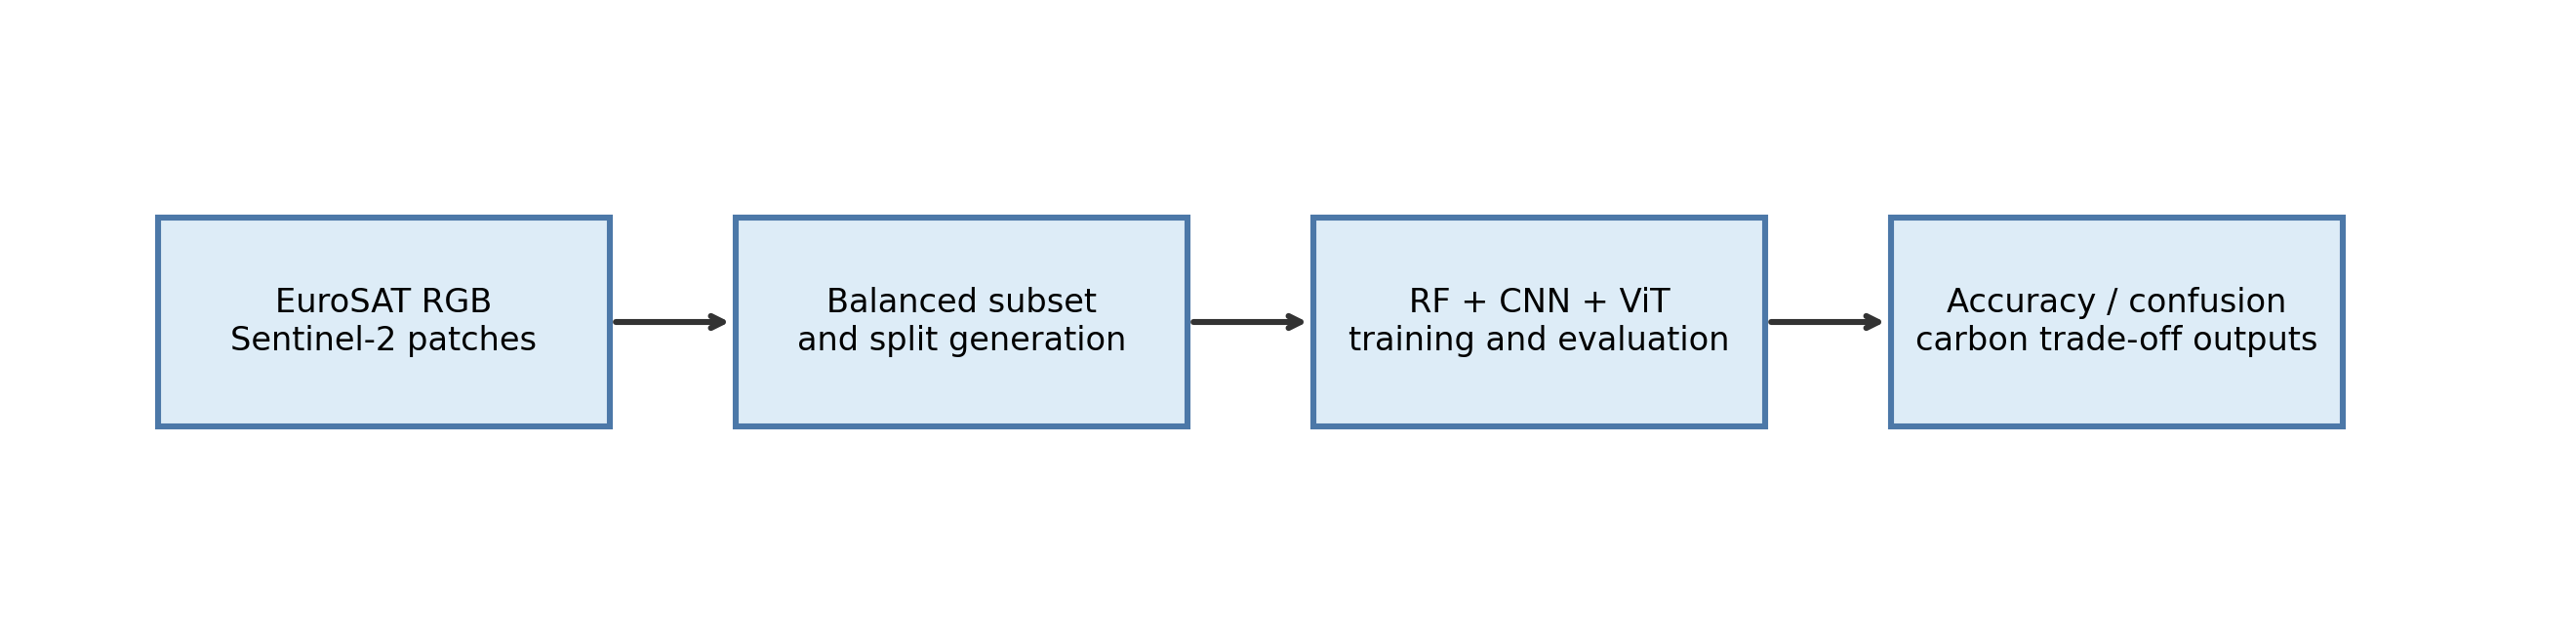

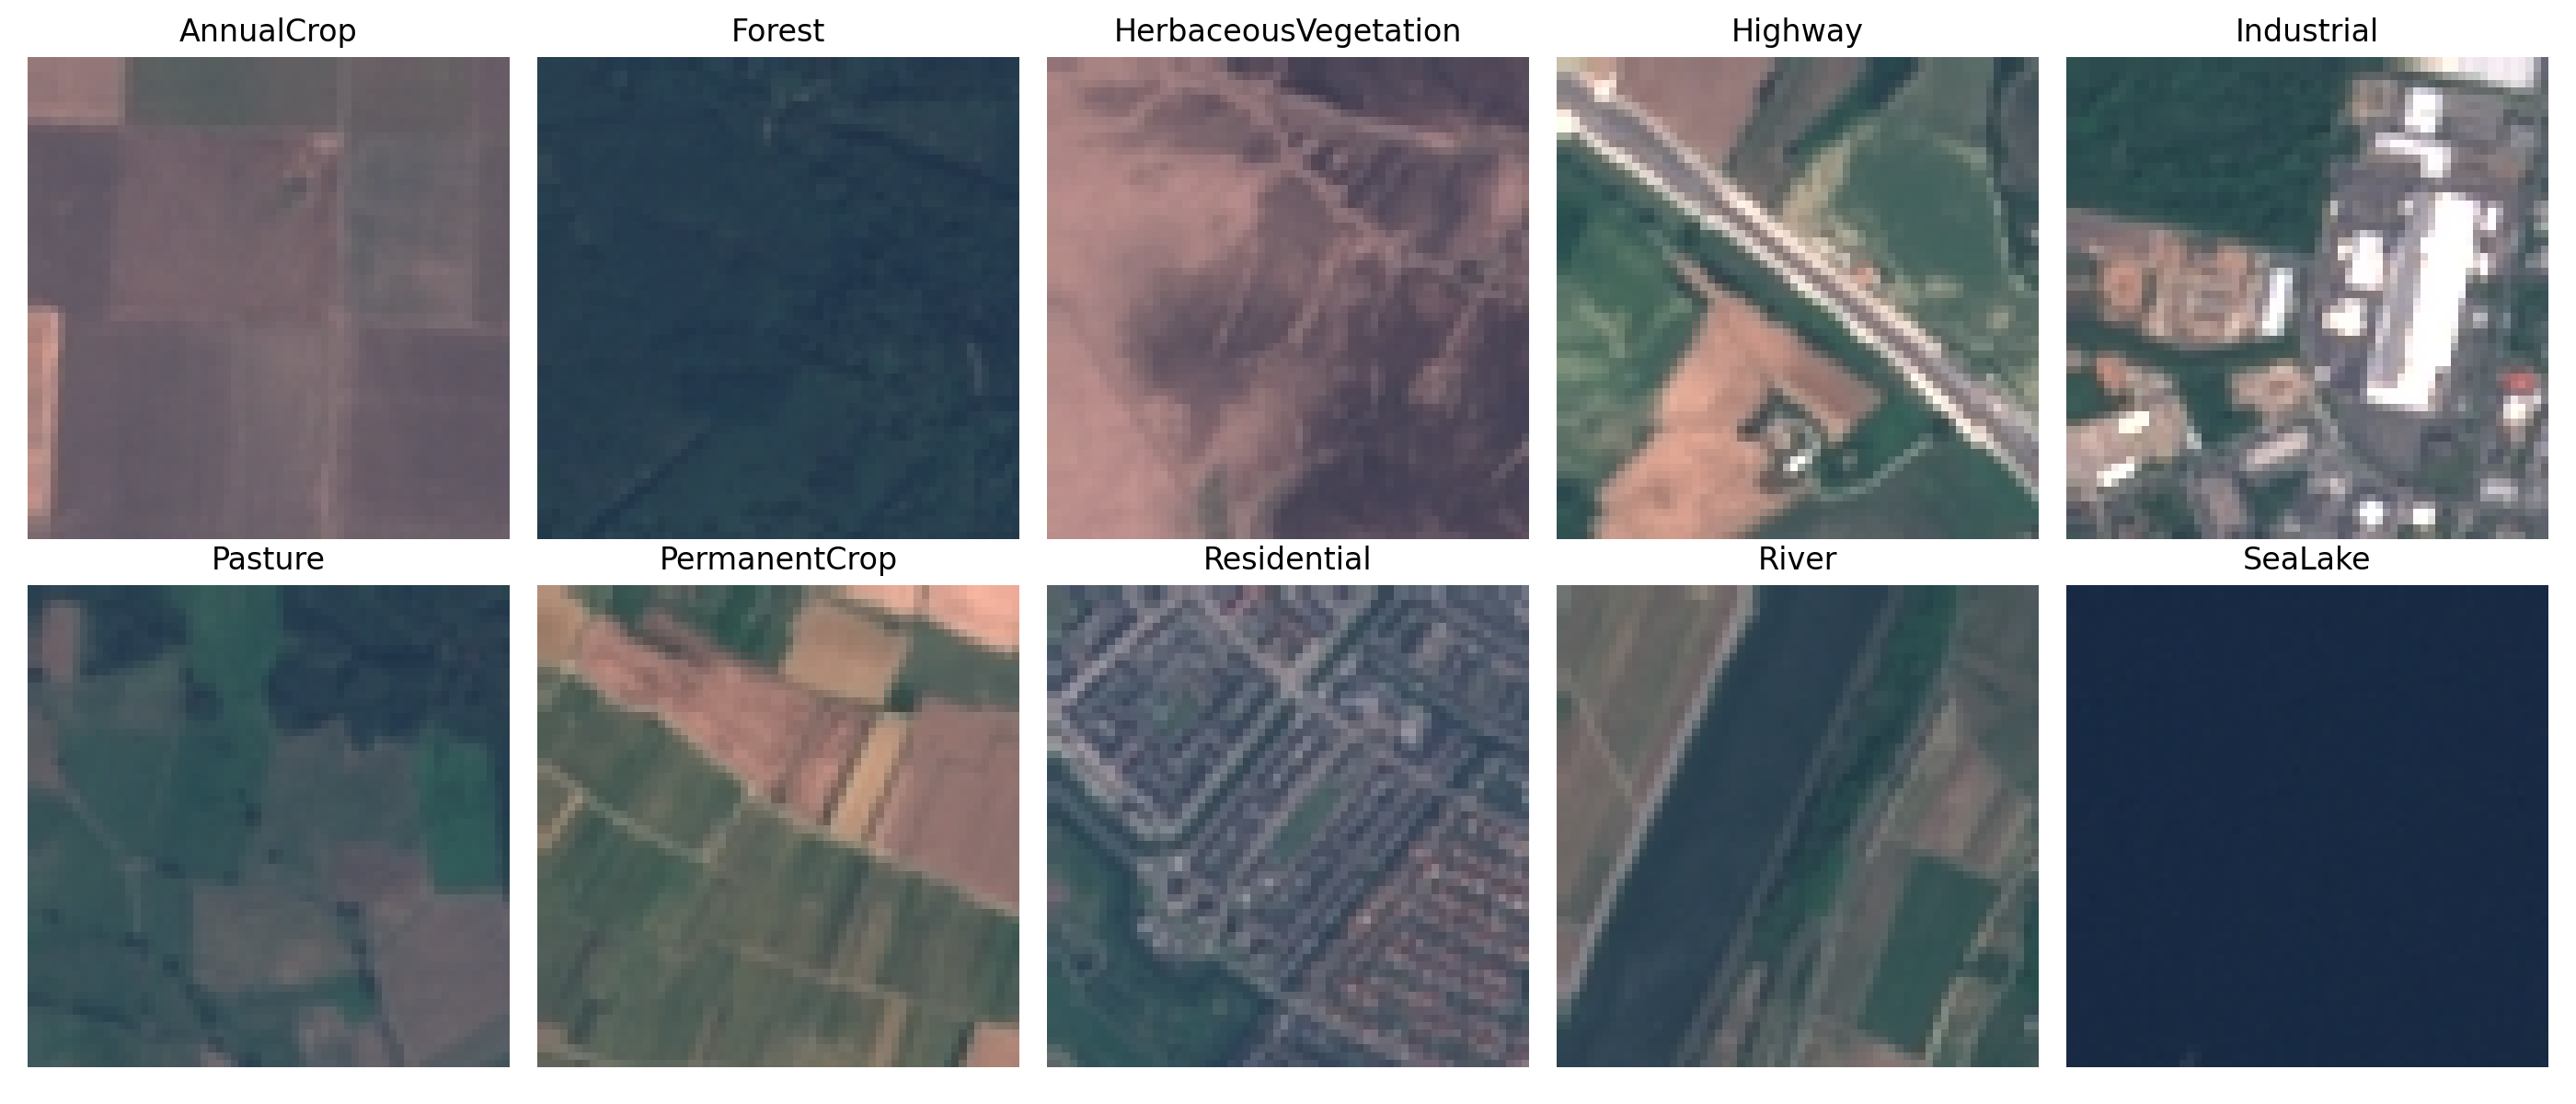

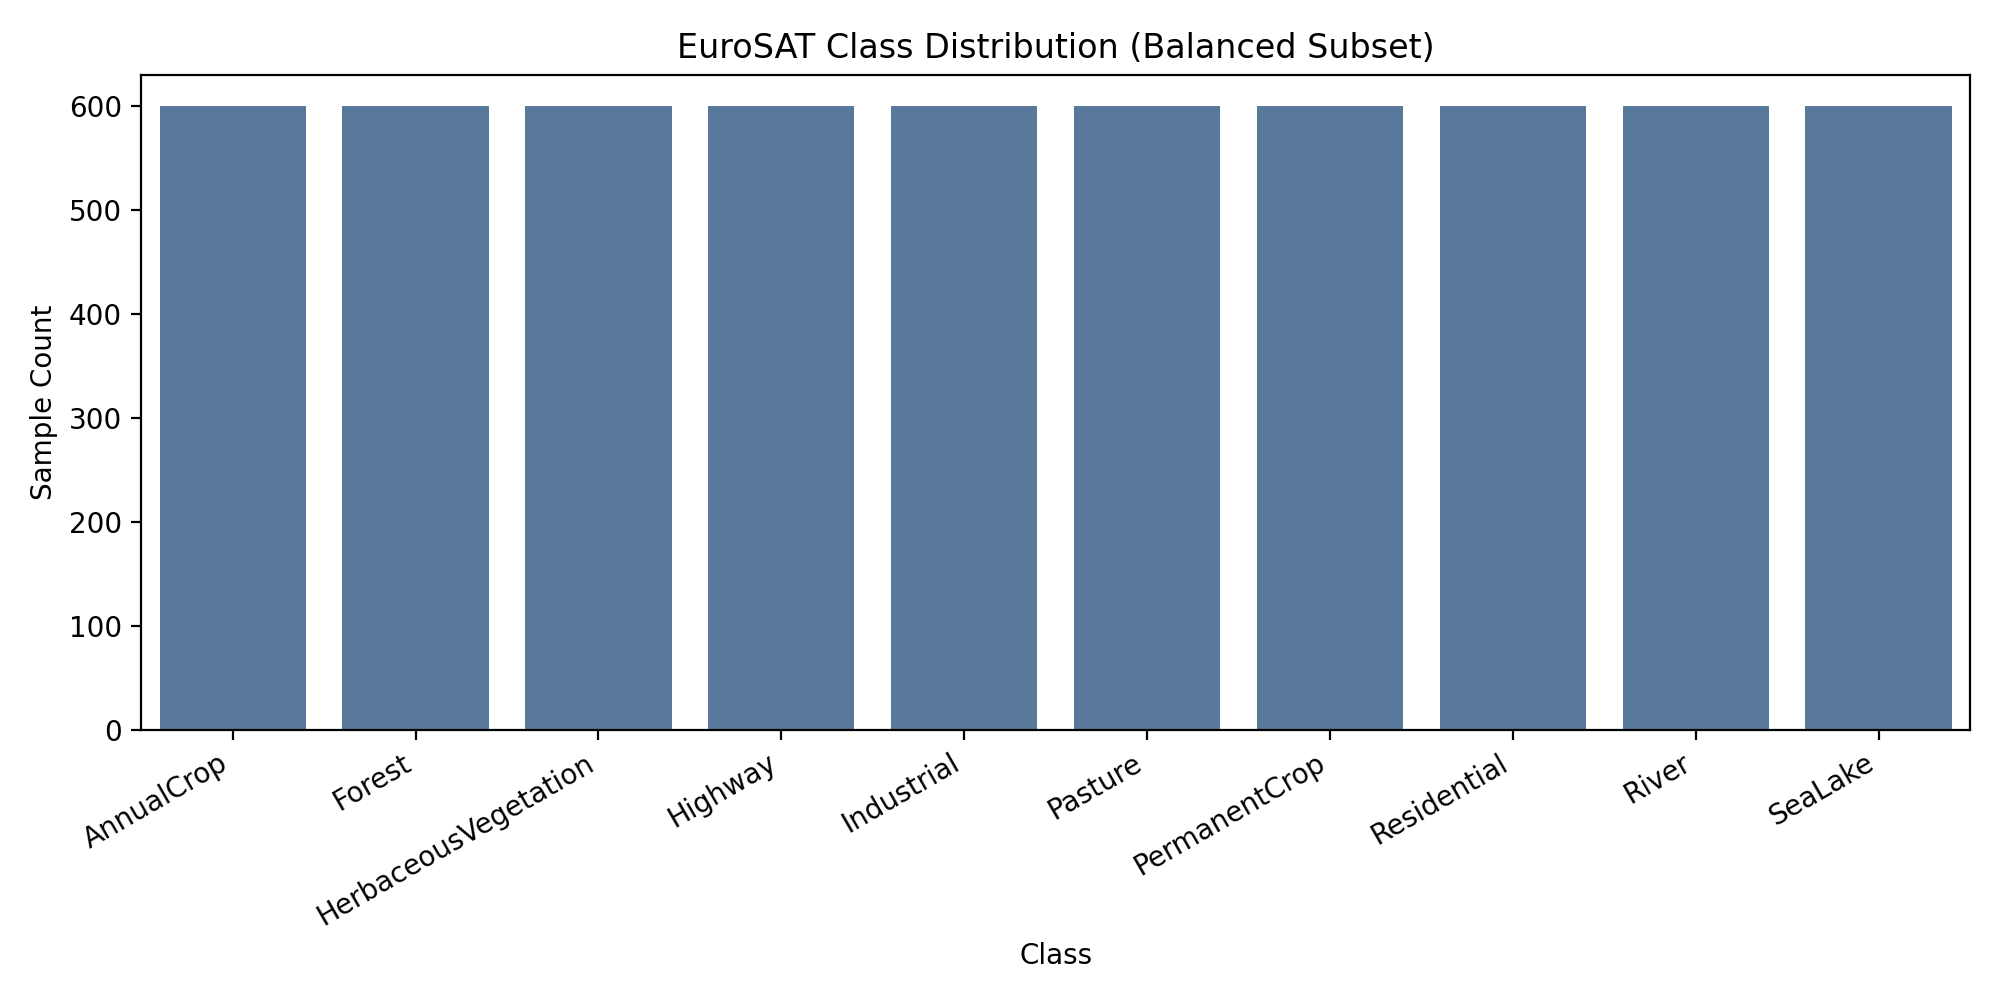

In [6]:
def plot_class_distribution(df):
    plt.figure(figsize=(10, 5))
    order = sorted(df['class_name'].unique())
    sns.countplot(data=df, x='class_name', order=order, color='#4C78A8')
    plt.xticks(rotation=30, ha='right')
    plt.title('EuroSAT Class Distribution (Balanced Subset)')
    plt.xlabel('Class')
    plt.ylabel('Sample Count')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'class_distribution.png', dpi=200)
    plt.close()

def plot_sample_grid(df):
    order = sorted(df['class_name'].unique())
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    axes = axes.flatten()
    for ax, class_name in zip(axes, order):
        sample_path = df[df['class_name'] == class_name]['image_path'].iloc[0]
        ax.imshow(Image.open(sample_path).convert('RGB'))
        ax.set_title(class_name)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'sample_grid.png', dpi=200)
    plt.close()

def plot_project_workflow():
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')
    x_positions = [0.05, 0.28, 0.51, 0.74]
    labels = [
        'EuroSAT RGB\nSentinel-2 patches',
        'Balanced subset\nand split generation',
        'RF + CNN + ViT\ntraining and evaluation',
        'Accuracy / confusion\ncarbon trade-off outputs'
    ]
    for x, label in zip(x_positions, labels):
        rect = plt.Rectangle((x, 0.32), 0.18, 0.36, facecolor='#DDECF7', edgecolor='#4C78A8', linewidth=2)
        ax.add_patch(rect)
        ax.text(x + 0.09, 0.50, label, ha='center', va='center', fontsize=11)
    for x1, x2 in [(0.23, 0.28), (0.46, 0.51), (0.69, 0.74)]:
        ax.annotate('', xy=(x2, 0.50), xytext=(x1, 0.50), arrowprops=dict(arrowstyle='->', lw=2, color='#333333'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'project_workflow_diagram.png', dpi=220)
    plt.close()

plot_class_distribution(df)
plot_sample_grid(df)
plot_project_workflow()
display(IPyImage(filename=str(FIG_DIR / 'project_workflow_diagram.png'), width=980))
display(IPyImage(filename=str(FIG_DIR / 'sample_grid.png'), width=980))
display(IPyImage(filename=str(FIG_DIR / 'class_distribution.png'), width=880))

## Random Forest Baseline

The first model branch is the Random Forest baseline. It is introduced first because it creates a meaningful non-deep-learning reference point before the notebook turns to pretrained neural models. Without that baseline, it would be much harder to evaluate whether the deep-learning gains are genuinely informative or simply assumed.

A key design choice is that the model does not use raw pixels directly. Instead, it uses color histograms, channel statistics, and coarse 2x2 spatial summaries, which are far better suited to tree-based learning. In that sense, the Random Forest branch is intentionally engineered to be a serious benchmark rather than an artificially weak baseline.

In [7]:
def prepare_rf_features(df):
    """Convert each RGB image into compact hand-crafted features for tree models."""
    features = []
    for path in df['image_path']:
        # Normalize resized RGB image to [0, 1] for stable feature scales.
        arr = np.asarray(Image.open(path).convert('RGB').resize((RF_STATS_IMAGE_SIZE, RF_STATS_IMAGE_SIZE)), dtype=np.float32) / 255.0
        feat = []

        # Per-channel histograms + summary statistics.
        for c in range(3):
            channel = arr[:, :, c]
            hist, _ = np.histogram(channel, bins=RF_HIST_BINS, range=(0.0, 1.0), density=True)
            feat.extend(hist.tolist())
            feat.extend([channel.mean(), channel.std(), channel.min(), channel.max()])

        # Coarse 2x2 spatial means to inject weak texture/layout cues.
        half = RF_STATS_IMAGE_SIZE // 2
        for c in range(3):
            channel = arr[:, :, c]
            feat.extend([
                channel[:half, :half].mean(),
                channel[:half, half:].mean(),
                channel[half:, :half].mean(),
                channel[half:, half:].mean(),
            ])
        features.append(np.array(feat, dtype=np.float32))
    return np.stack(features)

def plot_prediction_examples(df, y_true, y_pred, output_name, title, n_examples=8):
    """Visual panel with representative correct and incorrect predictions."""
    vis_df = df.copy().reset_index(drop=True)
    vis_df['true_label'] = list(y_true)
    vis_df['pred_label'] = list(y_pred)
    vis_df['is_correct'] = vis_df['true_label'] == vis_df['pred_label']

    # Sample across classes so the panel is not dominated by one class.
    correct_examples = vis_df[vis_df['is_correct']].groupby('true_label', sort=True).head(1)
    error_examples = vis_df[~vis_df['is_correct']].groupby('true_label', sort=True).head(1)
    selected = pd.concat([correct_examples, error_examples], ignore_index=True).head(n_examples)
    if len(selected) < n_examples:
        selected = pd.concat([selected, vis_df.head(n_examples - len(selected))], ignore_index=True)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for ax in axes:
        ax.axis('off')
    for ax, (_, row) in zip(axes, selected.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img)
        color = '#2E8B57' if row['is_correct'] else '#B22222'
        ax.set_title(f"T: {row['true_label']}\nP: {row['pred_label']}", fontsize=9, color=color)
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / output_name, dpi=220)
    plt.close()

def tune_random_forest(x_train, y_train, x_valid, y_valid):
    """Lightweight validation search; optimized for speed and reportability."""
    grid = [
        {'n_estimators': 400, 'max_features': 'sqrt', 'min_samples_leaf': 1},
        {'n_estimators': 700, 'max_features': 0.3, 'min_samples_leaf': 1},
        {'n_estimators': 700, 'max_features': 'sqrt', 'min_samples_leaf': 1},
        {'n_estimators': 700, 'max_features': 0.3, 'min_samples_leaf': 2},
    ]

    best = None
    best_score = -1.0
    for params in grid:
        candidate = RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=None,
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            n_jobs=-1,
            random_state=SEED,
        )
        candidate.fit(x_train, y_train)
        valid_pred = candidate.predict(x_valid)
        score = f1_score(y_valid, valid_pred, average='macro')
        if score > best_score:
            best_score = score
            best = params
    return best

def run_random_forest(train_df, valid_df, test_df, class_names):
    """Train RF with validation tuning, then evaluate once on held-out test."""
    x_train = prepare_rf_features(train_df)
    x_valid = prepare_rf_features(valid_df)
    x_test = prepare_rf_features(test_df)
    y_train = train_df['class_name'].to_numpy()
    y_valid = valid_df['class_name'].to_numpy()
    y_test = test_df['class_name'].to_numpy()

    best_params = tune_random_forest(x_train, y_train, x_valid, y_valid)

    # Retrain on train+valid after tuning for a stronger final model.
    x_train_full = np.concatenate([x_train, x_valid], axis=0)
    y_train_full = np.concatenate([y_train, y_valid], axis=0)

    model = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=None,
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        n_jobs=-1,
        random_state=SEED,
    )

    start = time.perf_counter()
    model.fit(x_train_full, y_train_full)
    y_pred = model.predict(x_test)
    runtime = time.perf_counter() - start

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    carbon = estimate_carbon(runtime)

    # Persist artifacts used later in report sections.
    pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().to_csv(MET_DIR / 'rf_classification_report.csv')
    save_confusion_matrix(y_test, y_pred, class_names, 'rf_confusion_matrix.png', 'Random Forest Confusion Matrix')
    plot_prediction_examples(test_df, y_test, y_pred, 'rf_prediction_examples.png', 'Random Forest Example Predictions')
    pd.DataFrame([best_params]).to_csv(MET_DIR / 'rf_tuning_result.csv', index=False)

    return {
        'method': 'RandomForest',
        'accuracy': float(accuracy),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'runtime_seconds': float(runtime),
        'carbon_kgco2e': float(carbon),
        'device': 'cpu',
    }

class_names = sorted(df['class_name'].unique())
rf_metrics = run_random_forest(train_df, valid_df, test_df, class_names)
rf_metrics

{'method': 'RandomForest',
 'accuracy': 0.7588888888888888,
 'macro_f1': 0.7534381708689066,
 'weighted_f1': 0.7534381708689066,
 'runtime_seconds': 4.825740270996903,
 'carbon_kgco2e': 6.876679886170586e-05,
 'device': 'cpu'}

## CNN Branch

With the classical baseline established, the notebook now moves into the first deep-learning branch. The CNN branch is important because it represents the most familiar transfer-learning strategy in practical image classification workflows.

Using pretrained ResNet18 means the notebook is not trying to build a very large custom architecture from scratch. Instead, it asks a more realistic methodological question: how far can a compact pretrained convolutional model improve over the engineered Random Forest baseline while still remaining practical on local GPU hardware?

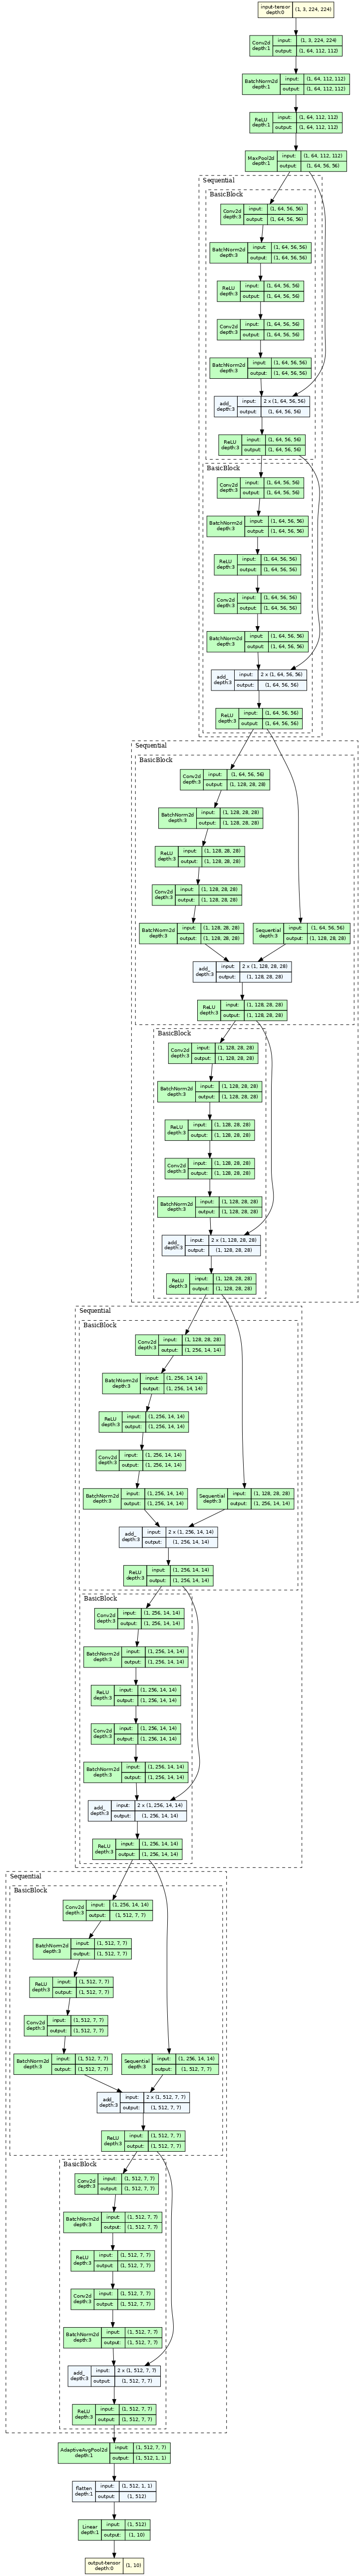

In [8]:
def build_cnn_model(num_classes):
    """Build transfer-learning CNN (ResNet18) with a task-specific classifier head."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Replace ImageNet head with EuroSAT-classification head.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # Freeze most backbone layers for stable/efficient fine-tuning.
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze last block to adapt high-level features to EO textures.
    for p in model.layer4.parameters():
        p.requires_grad = True

    # Always train the final classifier layer.
    for p in model.fc.parameters():
        p.requires_grad = True
    return model

def plot_cnn_architecture_diagram(model):
    """Export a structural diagram for report-ready model documentation."""
    graph = draw_graph(
        model,
        input_size=(1, 3, CNN_IMAGE_SIZE, CNN_IMAGE_SIZE),
        graph_name='CNN_Architecture',
        save_graph=True,
        filename='cnn_architecture_diagram',
        directory=str(FIG_DIR),
        expand_nested=True,
        depth=3,
    )
    return graph

plot_cnn_architecture_diagram(build_cnn_model(num_classes=10))
display(IPyImage(filename=str(FIG_DIR / 'cnn_architecture_diagram.png'), width=980))

### Shared Deep-Learning Utilities

Before training the CNN and the ViT, the notebook defines one shared layer of deep-learning utilities. This includes the dataset wrapper, data transforms, evaluation function, training-curve plotting, and the common fine-tuning loop.

That shared layer matters because it means the two deep branches differ mainly in architecture rather than in surrounding training logic. As a result, the later comparison is methodologically cleaner and easier to trust.

In [9]:
class EuroSATDataset(Dataset):
    """Minimal dataset wrapper around split manifests."""
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = self.class_to_idx[row['class_name']]
        return image, label

def evaluate_model(model, loader, device):
    """Run inference and return integer labels/predictions."""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=device.type == 'cuda')
            labels = labels.to(device, non_blocking=device.type == 'cuda')
            with autocast(enabled=device.type == 'cuda'):
                logits = model(images)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    return np.array(all_labels), np.array(all_preds)

def get_loaders(train_df, valid_df, test_df, class_to_idx, image_size, batch_size):
    """Create train/valid/test dataloaders with matching normalization."""
    train_transform = transforms.Compose([
        # Mild augmentations to improve robustness without heavy distribution shift.
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    use_cuda = torch.cuda.is_available()
    loader_kwargs = {'num_workers': 0, 'pin_memory': use_cuda}

    train_loader = DataLoader(
        EuroSATDataset(train_df, class_to_idx, train_transform),
        batch_size=batch_size,
        shuffle=True,
        **loader_kwargs,
    )
    valid_loader = DataLoader(
        EuroSATDataset(valid_df, class_to_idx, eval_transform),
        batch_size=batch_size,
        shuffle=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        EuroSATDataset(test_df, class_to_idx, eval_transform),
        batch_size=batch_size,
        shuffle=False,
        **loader_kwargs,
    )
    return train_loader, valid_loader, test_loader

def plot_training_history(history_df, model_name, output_path):
    """Save side-by-side loss/accuracy curves for report diagnostics."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o')
    axes[0].set_title(f'{model_name} Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(history_df['epoch'], history_df['train_accuracy'], marker='o', label='Train')
    axes[1].plot(history_df['epoch'], history_df['valid_accuracy'], marker='o', label='Validation')
    axes[1].set_title(f'{model_name} Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=220)
    plt.close()

def train_classifier(model, model_name, train_loader, valid_loader, test_loader, idx_to_class, class_names, epochs, lr):
    """Generic fine-tuning loop shared by CNN and ViT branches."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Only optimize trainable parameters (others are frozen).
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    use_amp = device.type == 'cuda'
    scaler = GradScaler(enabled=use_amp)

    history = []
    start = time.perf_counter()
    best_state = None
    best_valid_acc = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=use_amp)
            labels = labels.to(device, non_blocking=use_amp)

            optimizer.zero_grad()
            with autocast(enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation score controls checkpoint selection.
        valid_true, valid_pred = evaluate_model(model, valid_loader, device)
        valid_acc = accuracy_score(valid_true, valid_pred)

        history.append({
            'epoch': epoch,
            'train_loss': float(train_loss),
            'train_accuracy': float(train_acc),
            'valid_accuracy': float(valid_acc),
        })

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

        scheduler.step()

    # Restore best validation checkpoint before final test evaluation.
    if best_state is not None:
        model.load_state_dict(best_state)

    model = model.to(device)
    y_true_idx, y_pred_idx = evaluate_model(model, test_loader, device)
    runtime = time.perf_counter() - start

    y_true = [idx_to_class[i] for i in y_true_idx]
    y_pred = [idx_to_class[i] for i in y_pred_idx]

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    carbon = estimate_carbon(runtime)

    method_slug = model_name.lower()

    # Export metrics/artifacts used by downstream report cells.
    pd.DataFrame(history).to_csv(MET_DIR / f'{method_slug}_training_history.csv', index=False)
    pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).transpose().to_csv(MET_DIR / f'{method_slug}_classification_report.csv')
    save_confusion_matrix(y_true, y_pred, class_names, f'{method_slug}_confusion_matrix.png', f'{model_name} Confusion Matrix')
    plot_training_history(pd.DataFrame(history), model_name, FIG_DIR / f'{method_slug}_training_history.png')

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return {
        'method': model_name,
        'accuracy': float(accuracy),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'runtime_seconds': float(runtime),
        'carbon_kgco2e': float(carbon),
        'device': device.type,
        'y_true': y_true,
        'y_pred': y_pred,
    }

In [10]:
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
train_loader_cnn, valid_loader_cnn, test_loader_cnn = get_loaders(train_df, valid_df, test_df, class_to_idx, CNN_IMAGE_SIZE, BATCH_SIZE_CNN)
cnn_model = build_cnn_model(num_classes=len(class_names))
cnn_metrics = train_classifier(cnn_model, 'CNN', train_loader_cnn, valid_loader_cnn, test_loader_cnn, idx_to_class, class_names, CNN_EPOCHS, 3e-4)
plot_prediction_examples(test_df, cnn_metrics['y_true'], cnn_metrics['y_pred'], 'cnn_prediction_examples.png', 'CNN Example Predictions')
cnn_metrics.pop('y_true')
cnn_metrics.pop('y_pred')
cnn_metrics

{'method': 'CNN',
 'accuracy': 0.9611111111111111,
 'macro_f1': 0.9610157295781002,
 'weighted_f1': 0.9610157295781003,
 'runtime_seconds': 549.2472646380011,
 'carbon_kgco2e': 0.007826773521091514,
 'device': 'cuda'}

## ViT Branch

The final model branch fine-tunes a pretrained ViT-B/16. This branch extends the comparison beyond convolutional transfer learning and asks whether a transformer-based representation can produce an additional improvement on the same benchmark.

Including ViT makes the notebook methodologically richer because the comparison now spans three traditions: classical machine learning, convolutional transfer learning, and transformer-based vision modeling.

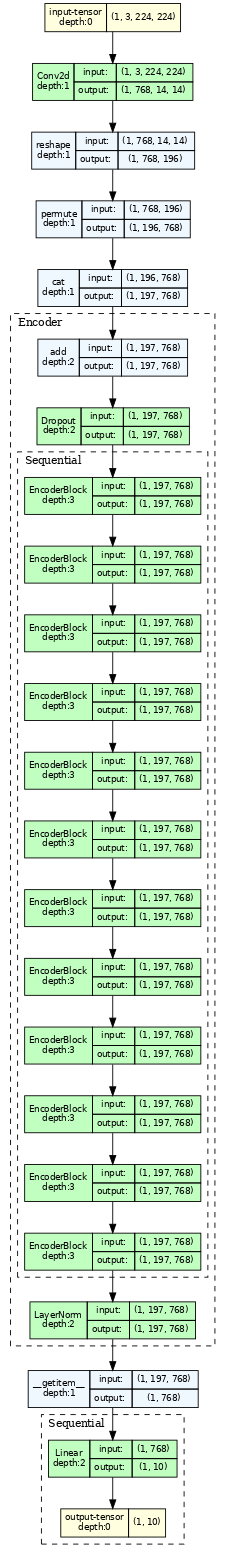

In [11]:
def build_vit_model(num_classes):
    """Build transfer-learning ViT-B/16 with partial encoder unfreezing."""
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

    # Replace ImageNet classification head.
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)

    # Freeze all weights first.
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze last two transformer encoder blocks for adaptation capacity.
    for name, p in model.named_parameters():
        if name.startswith('encoder.layers.encoder_layer_10') or name.startswith('encoder.layers.encoder_layer_11'):
            p.requires_grad = True

    # Always train new task head.
    for p in model.heads.parameters():
        p.requires_grad = True
    return model

def plot_vit_architecture_diagram(model):
    """Export ViT architecture diagram for technical reporting."""
    graph = draw_graph(
        model,
        input_size=(1, 3, VIT_IMAGE_SIZE, VIT_IMAGE_SIZE),
        graph_name='ViT_Architecture',
        save_graph=True,
        filename='vit_architecture_diagram',
        directory=str(FIG_DIR),
        expand_nested=True,
        depth=3,
    )
    return graph

plot_vit_architecture_diagram(build_vit_model(num_classes=10))
display(IPyImage(filename=str(FIG_DIR / 'vit_architecture_diagram.png'), width=980))

In [12]:
train_loader_vit, valid_loader_vit, test_loader_vit = get_loaders(train_df, valid_df, test_df, class_to_idx, VIT_IMAGE_SIZE, BATCH_SIZE_VIT)
vit_model = build_vit_model(num_classes=len(class_names))
vit_metrics = train_classifier(vit_model, 'ViT', train_loader_vit, valid_loader_vit, test_loader_vit, idx_to_class, class_names, VIT_EPOCHS, 2e-4)
plot_prediction_examples(test_df, vit_metrics['y_true'], vit_metrics['y_pred'], 'vit_prediction_examples.png', 'ViT Example Predictions')
vit_metrics.pop('y_true')
vit_metrics.pop('y_pred')
vit_metrics

{'method': 'ViT',
 'accuracy': 0.9733333333333334,
 'macro_f1': 0.9732984291245481,
 'weighted_f1': 0.9732984291245481,
 'runtime_seconds': 1137.7905176839995,
 'carbon_kgco2e': 0.01621351487699699,
 'device': 'cuda'}

## Aggregate Comparison and Export

Once all three branches have been trained independently, the notebook moves into aggregation. At this point the task is no longer model development, but synthesis: bringing separate outputs together into one coherent comparison study.

In [13]:
def plot_tradeoff(metrics_df):
    """Bubble chart: x=runtime, y=accuracy, bubble size=estimated carbon."""
    plt.figure(figsize=(8, 5))
    colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

    # Scale bubble area so tiny RF emissions remain visible on the same axis.
    plt.scatter(
        metrics_df['runtime_seconds'],
        metrics_df['accuracy'],
        s=metrics_df['carbon_kgco2e'] * 400000 + 150,
        c=colors[:len(metrics_df)],
        alpha=0.8,
    )

    for _, row in metrics_df.iterrows():
        plt.annotate(row['method'], (row['runtime_seconds'], row['accuracy']), xytext=(6, 6), textcoords='offset points')

    plt.xlabel('Runtime (seconds)')
    plt.ylabel('Accuracy')
    plt.title('Accuracy-Runtime-Carbon Trade-off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'accuracy_runtime_carbon_tradeoff.png', dpi=220)
    plt.close()

# Consolidate all method-level metrics for export and report rendering.
metrics_df = pd.DataFrame([rf_metrics, cnn_metrics, vit_metrics])
metrics_df.to_csv(MET_DIR / 'all_method_metrics.csv', index=False)
metrics_df.to_csv(TAB_DIR / 'method_tradeoff_summary.csv', index=False)

# Build environment-cost table with explicit assumptions.
env_table = metrics_df[['method', 'runtime_seconds', 'carbon_kgco2e', 'device']].copy()
env_table['average_power_watts'] = CARBON_ASSUMPTIONS['average_power_watts']
env_table['pue'] = CARBON_ASSUMPTIONS['pue']
env_table['carbon_intensity_gco2_per_kwh'] = CARBON_ASSUMPTIONS['carbon_intensity_gco2_per_kwh']
env_table.to_csv(TAB_DIR / 'environment_scenario_comparison.csv', index=False)

plot_tradeoff(metrics_df)

summary = {
    'dataset': 'EuroSAT_RGB balanced subset',
    'total_samples': int(len(df)),
    'classes': class_names,
    'class_limit': CLASS_LIMIT,
    'best_accuracy': float(metrics_df['accuracy'].max()),
    'best_method': str(metrics_df.loc[metrics_df['accuracy'].idxmax(), 'method']),
    'total_estimated_carbon_kgco2e': float(metrics_df['carbon_kgco2e'].sum()),
    'methods': metrics_df.to_dict(orient='records')
}

with open(MET_DIR / 'summary_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, allow_nan=False)

summary

{'dataset': 'EuroSAT_RGB balanced subset',
 'total_samples': 6000,
 'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_limit': 600,
 'best_accuracy': 0.9733333333333334,
 'best_method': 'ViT',
 'total_estimated_carbon_kgco2e': 0.02410905519695021,
 'methods': [{'method': 'RandomForest',
   'accuracy': 0.7588888888888888,
   'macro_f1': 0.7534381708689066,
   'weighted_f1': 0.7534381708689066,
   'runtime_seconds': 4.825740270996903,
   'carbon_kgco2e': 6.876679886170586e-05,
   'device': 'cpu'},
  {'method': 'CNN',
   'accuracy': 0.9611111111111111,
   'macro_f1': 0.9610157295781002,
   'weighted_f1': 0.9610157295781003,
   'runtime_seconds': 549.2472646380011,
   'carbon_kgco2e': 0.007826773521091514,
   'device': 'cuda'},
  {'method': 'ViT',
   'accuracy': 0.9733333333333334,
   'macro_f1': 0.9732984291245481,
   'weighted_f1': 0.9732984291245481,
   'runtime_se

## Results and Comparative Evidence

With all branches executed, the notebook can now move from implementation into interpretation. The summary table below is the main quantitative comparison point, but it is not the end of the story.

What matters next is to explain where the numerical differences come from, how they appear visually, and how they should be judged once computational cost is included.

In [14]:
method_summary = pd.read_csv(TAB_DIR / 'method_tradeoff_summary.csv')
method_summary

,method,accuracy,macro_f1,weighted_f1,runtime_seconds,carbon_kgco2e,device
0,RandomForest,0.758889,0.753438,0.753438,4.825740,0.000069,cpu
1,CNN,0.961111,0.961016,0.961016,549.247265,0.007827,cuda
2,ViT,0.973333,0.973298,0.973298,1137.790518,0.016214,cuda


### Confusion Evidence

Confusion matrices provide a more interpretable view of model behavior than a single scalar metric. They reveal which class boundaries remain difficult and whether the deep models are genuinely reducing systematic confusion rather than only increasing the overall score.

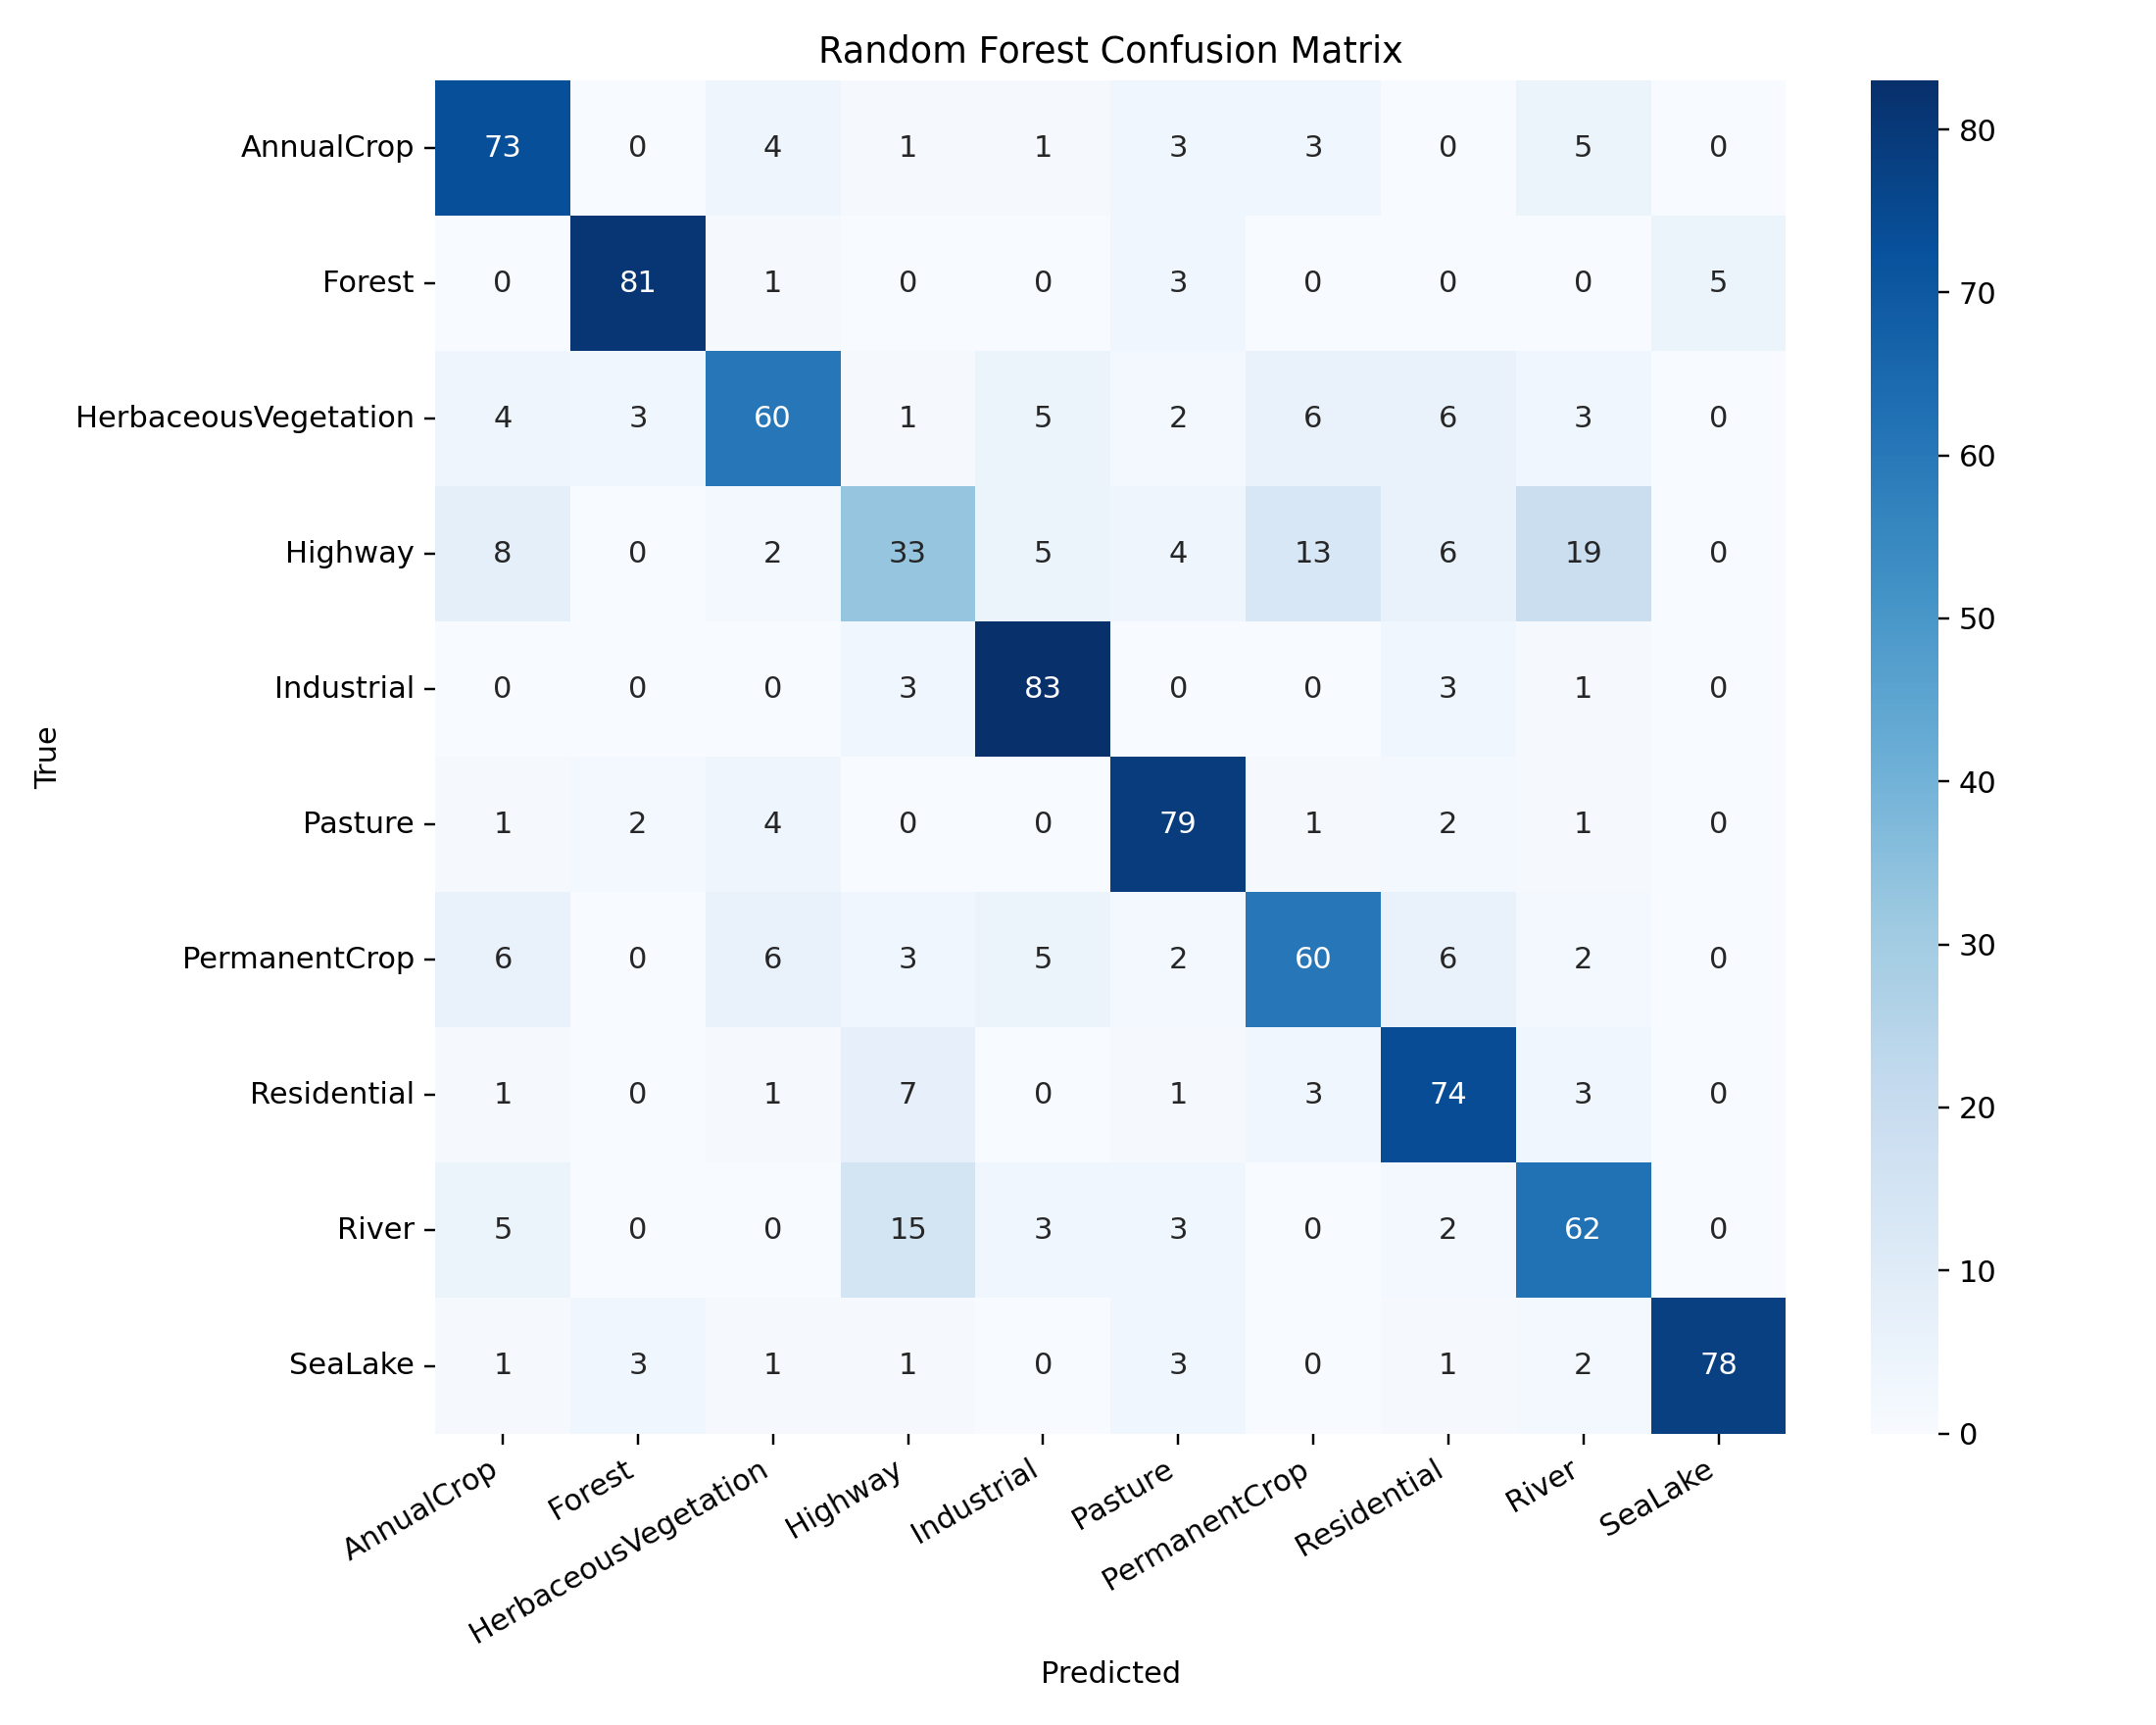

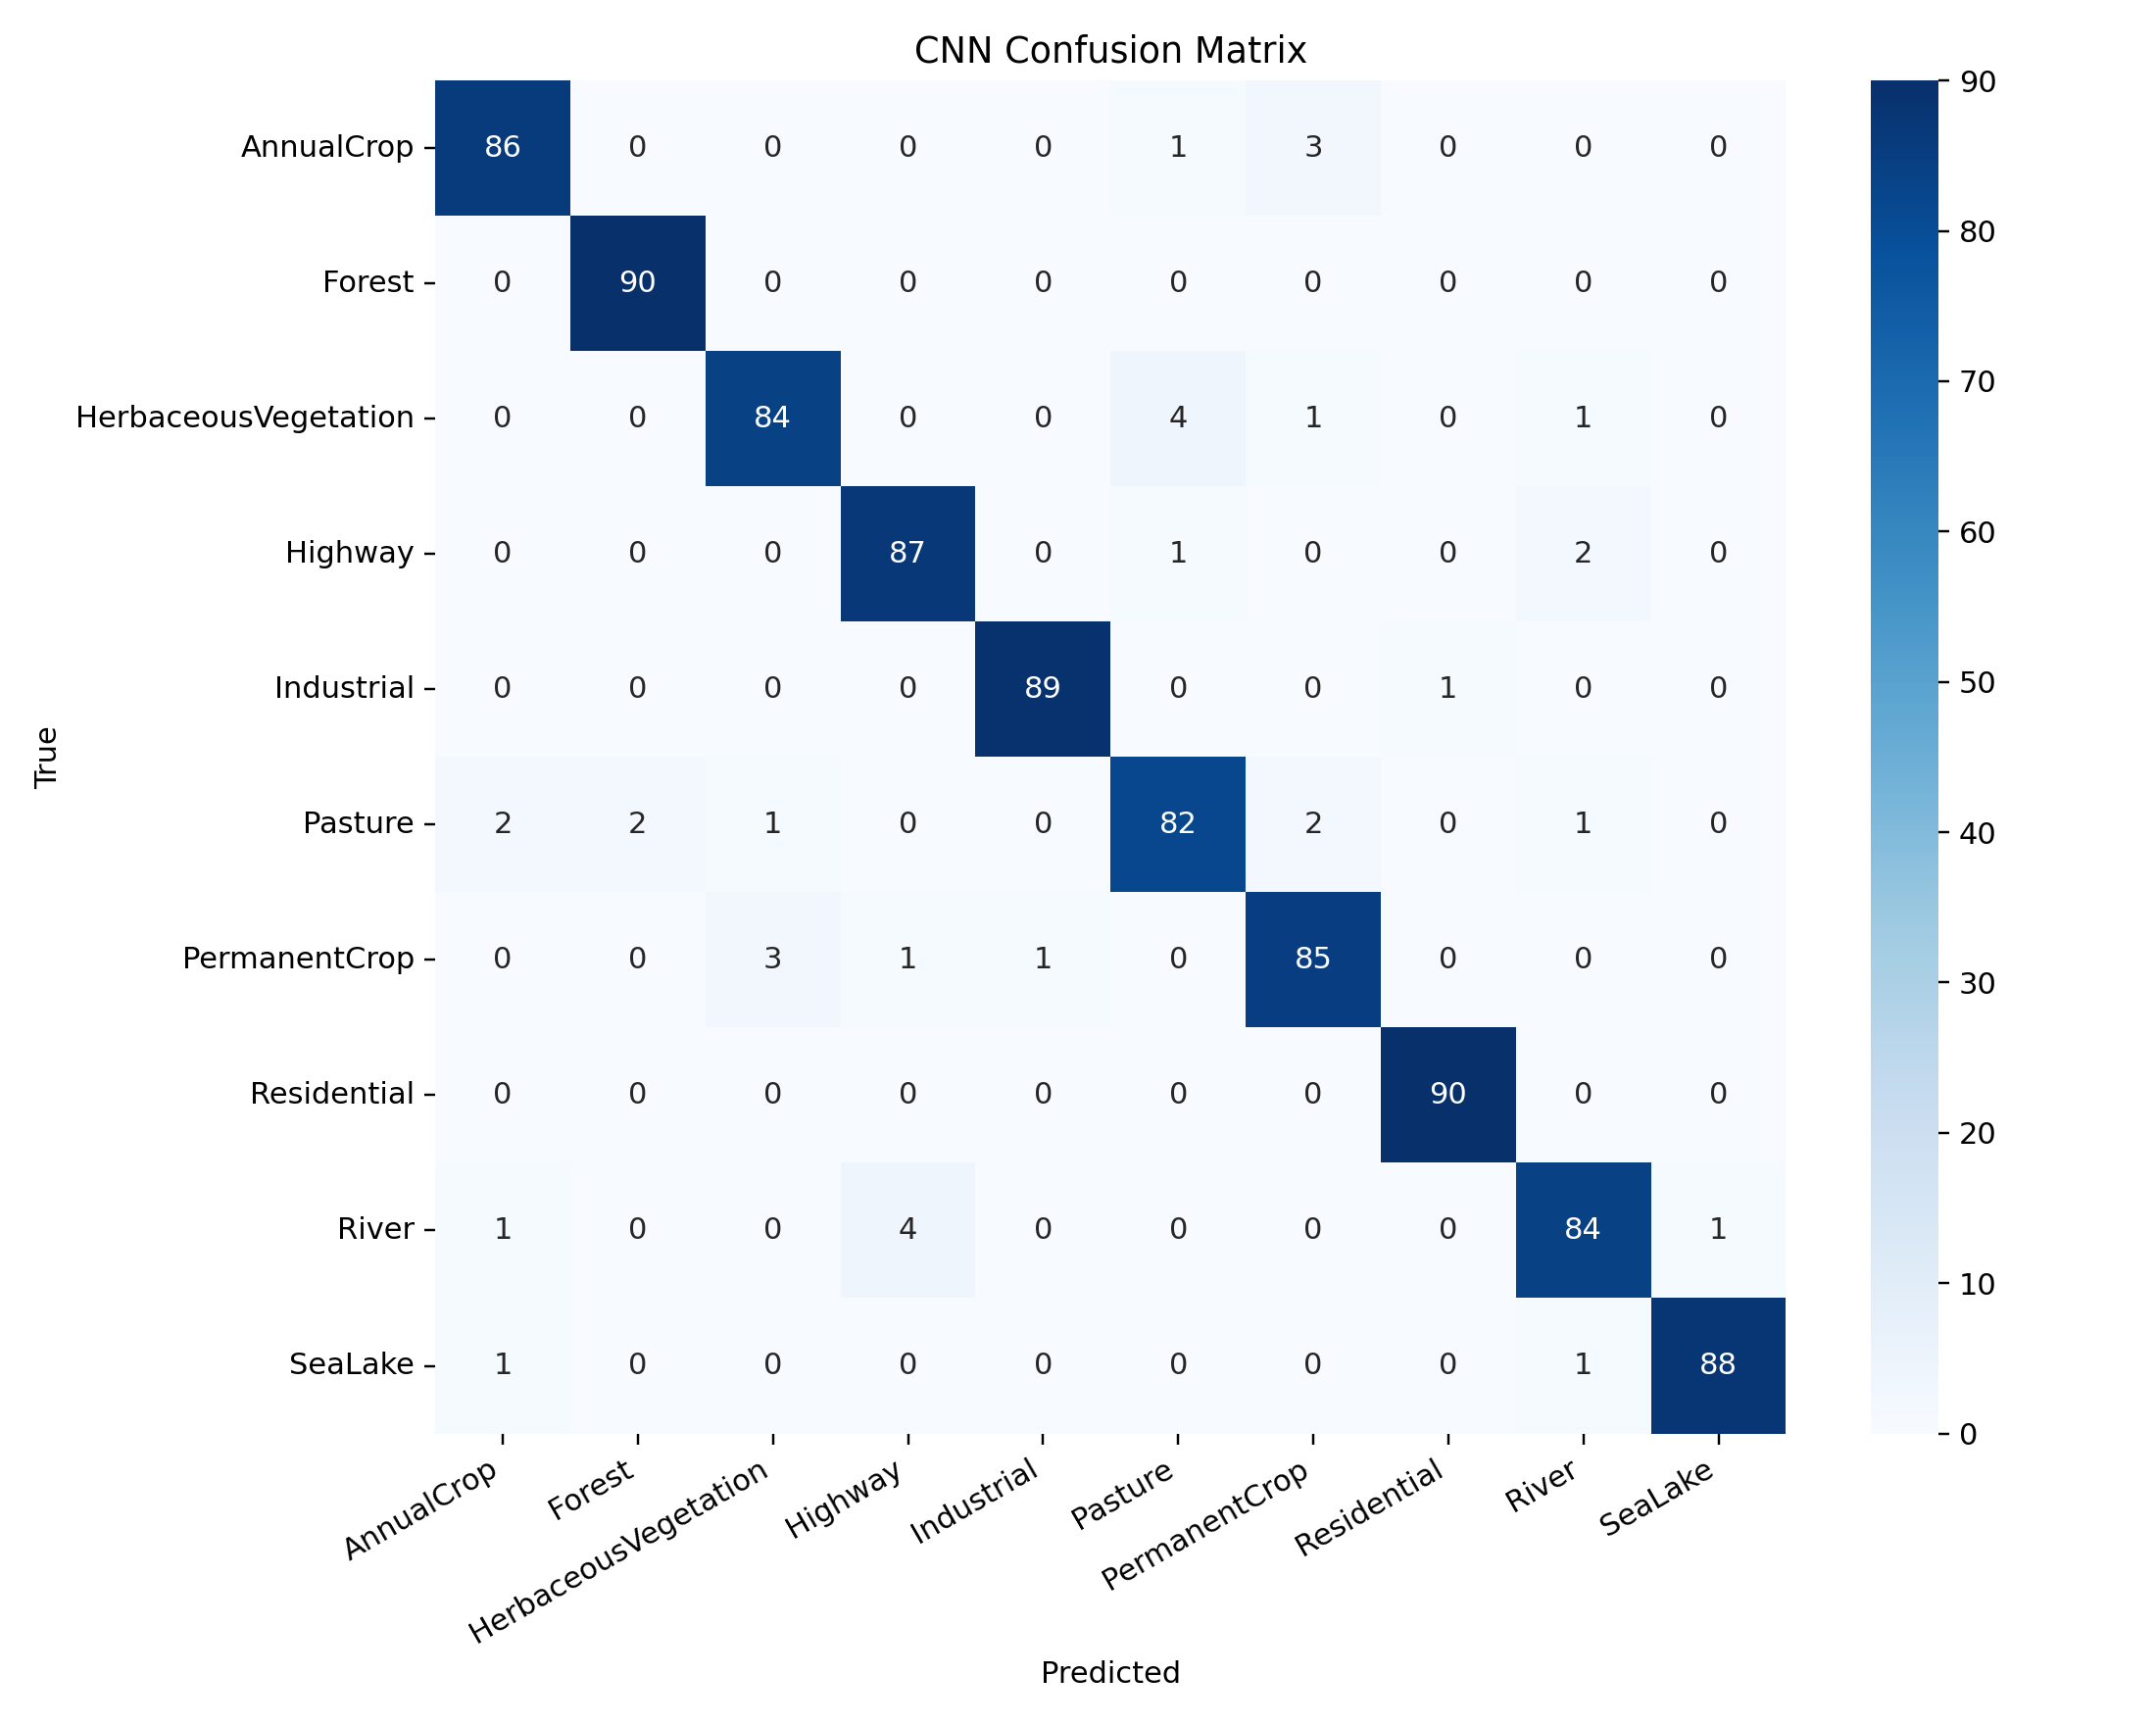

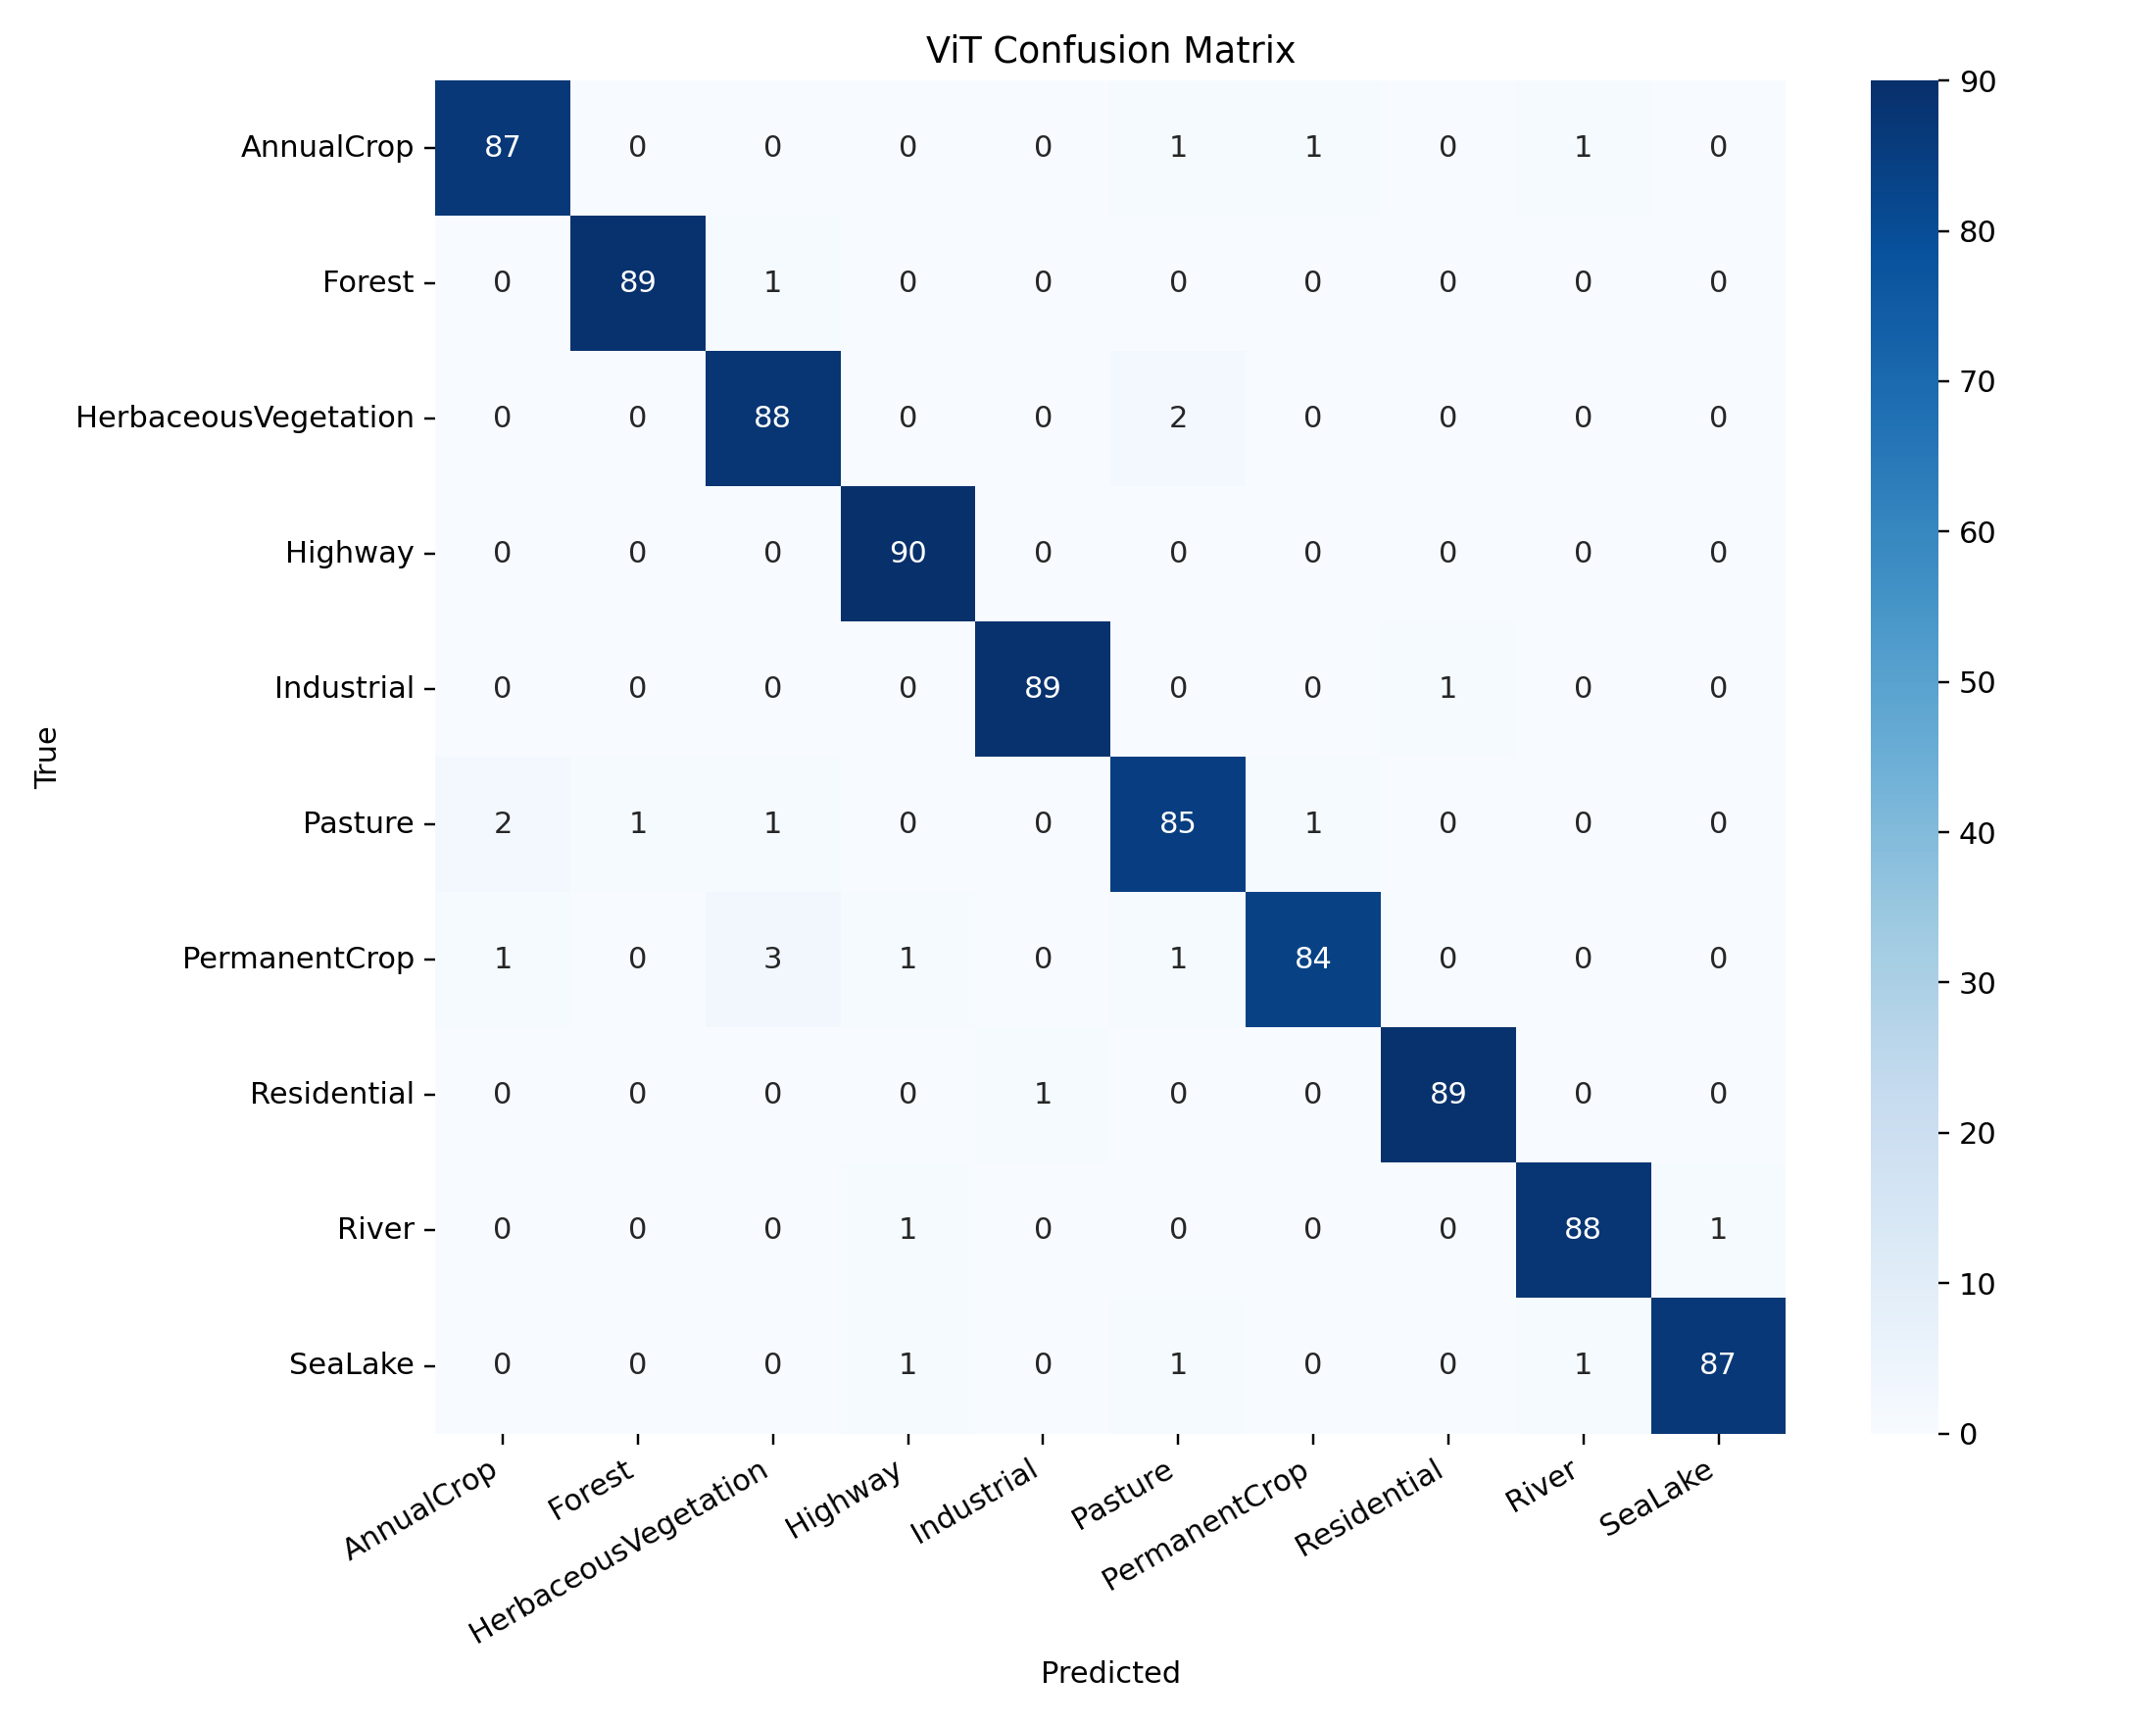

In [15]:
display(IPyImage(filename=str(FIG_DIR / 'rf_confusion_matrix.png'), width=820))
display(IPyImage(filename=str(FIG_DIR / 'cnn_confusion_matrix.png'), width=820))
display(IPyImage(filename=str(FIG_DIR / 'vit_confusion_matrix.png'), width=820))

### Qualitative Prediction Examples

To complement the confusion matrices, the notebook also includes representative prediction panels. These examples make the comparison feel more concrete because they connect the abstract metrics back to real Sentinel-2 image content.

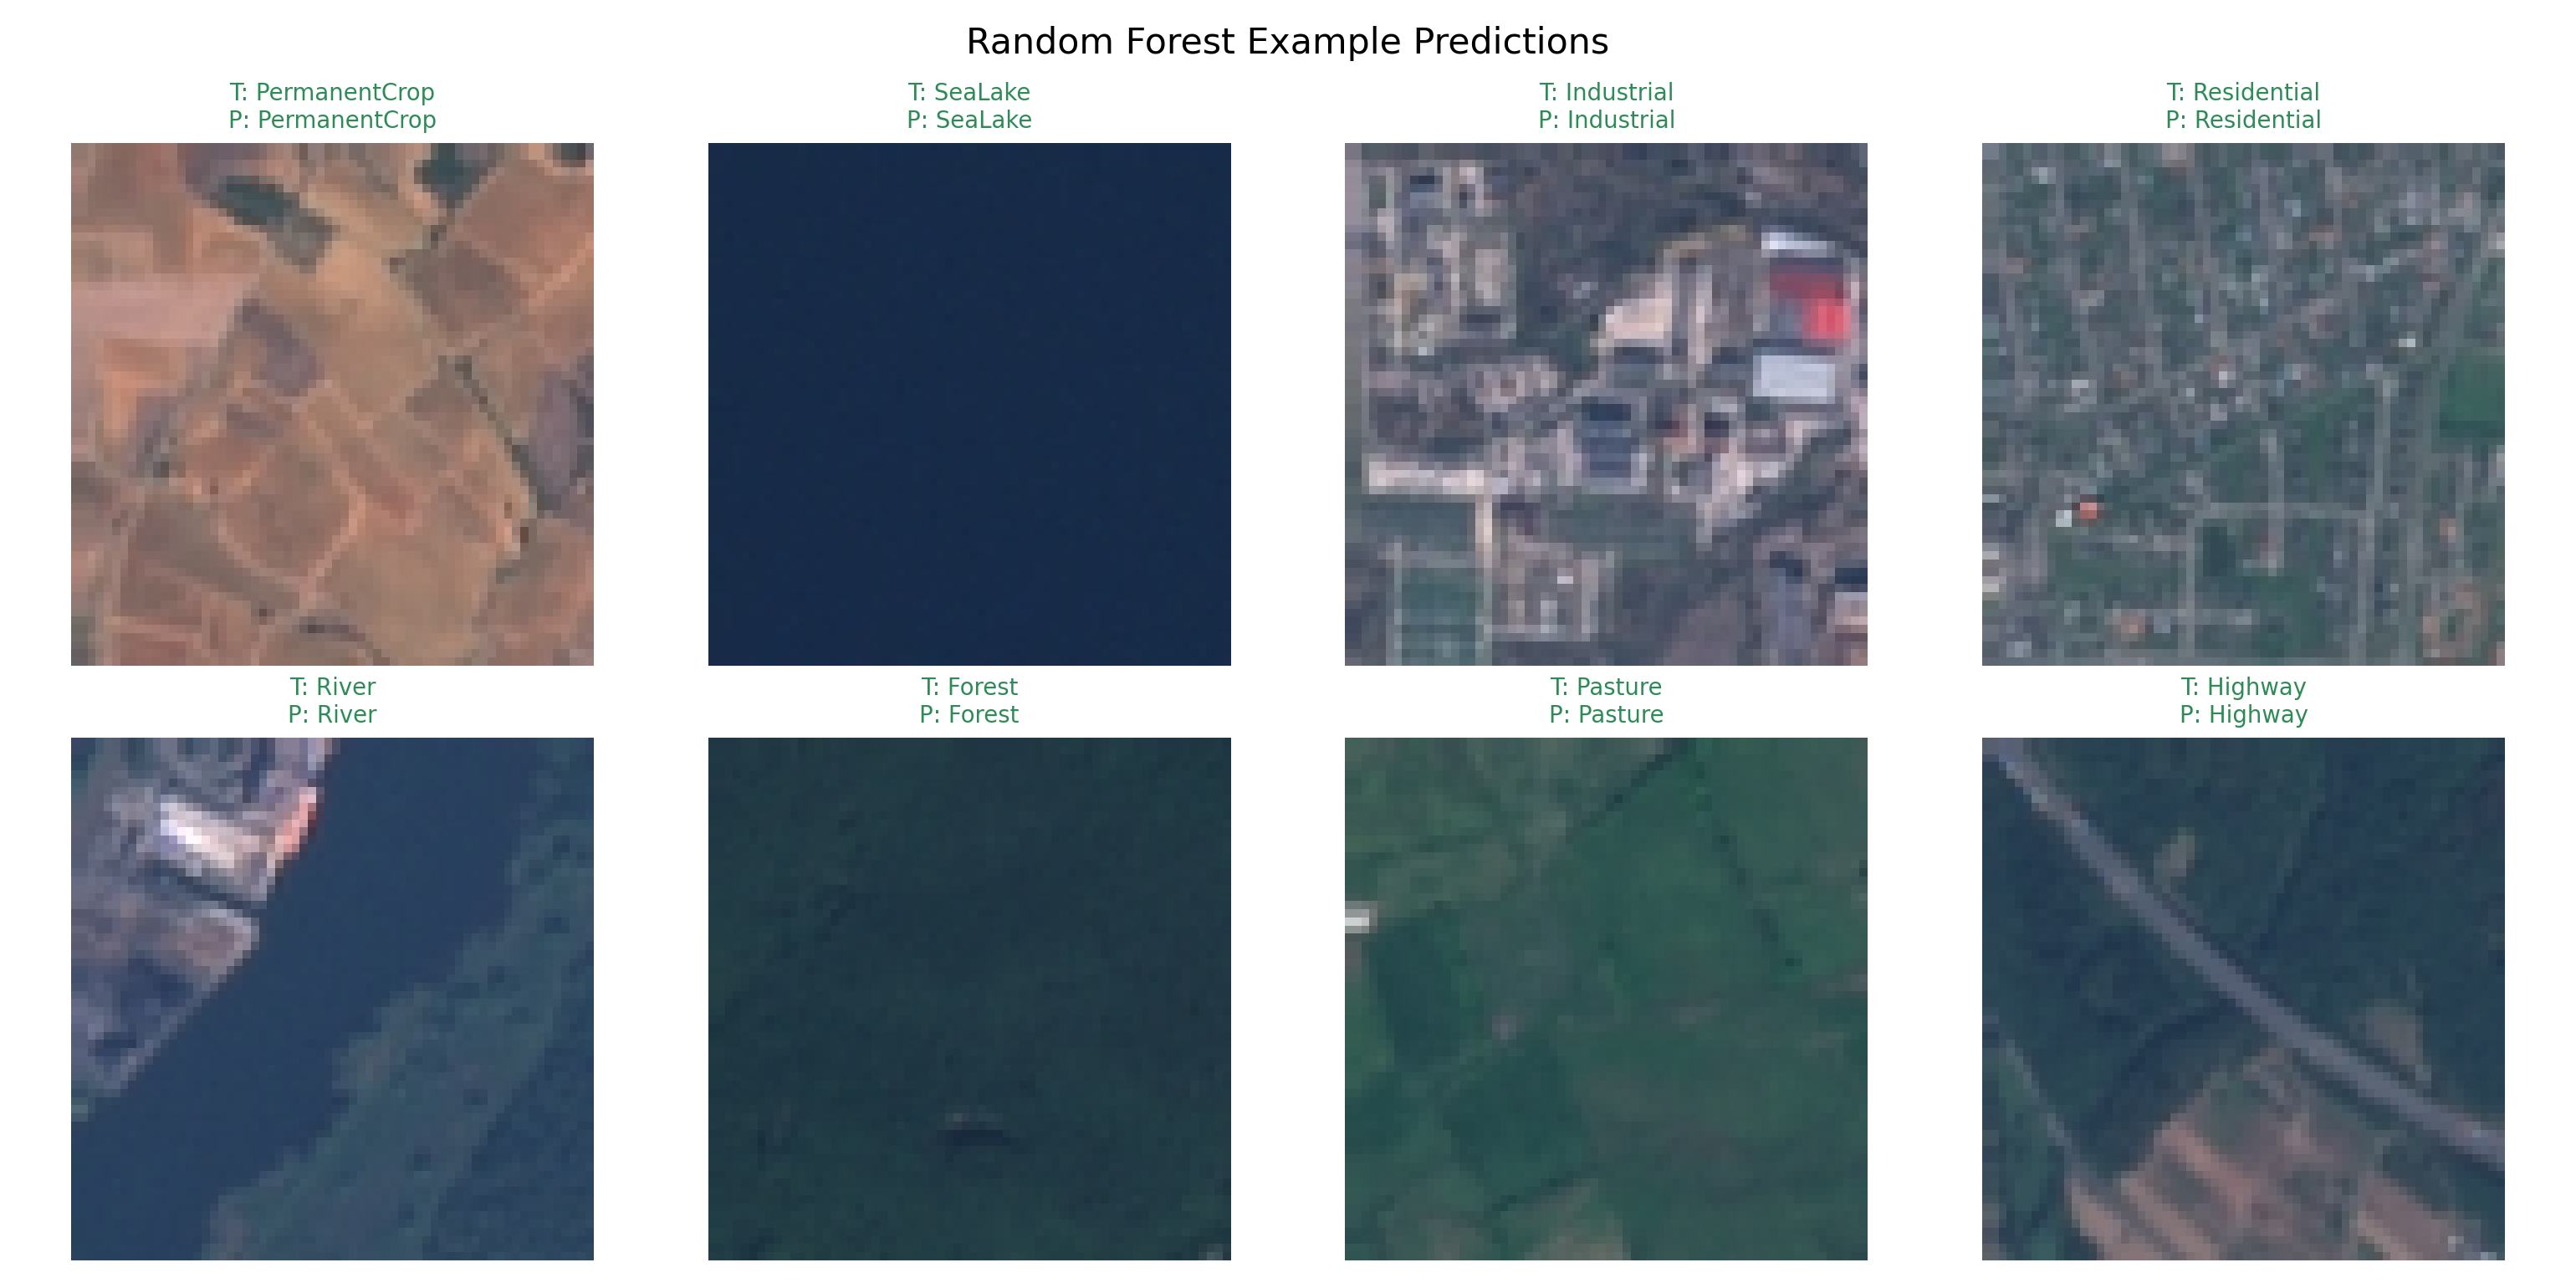

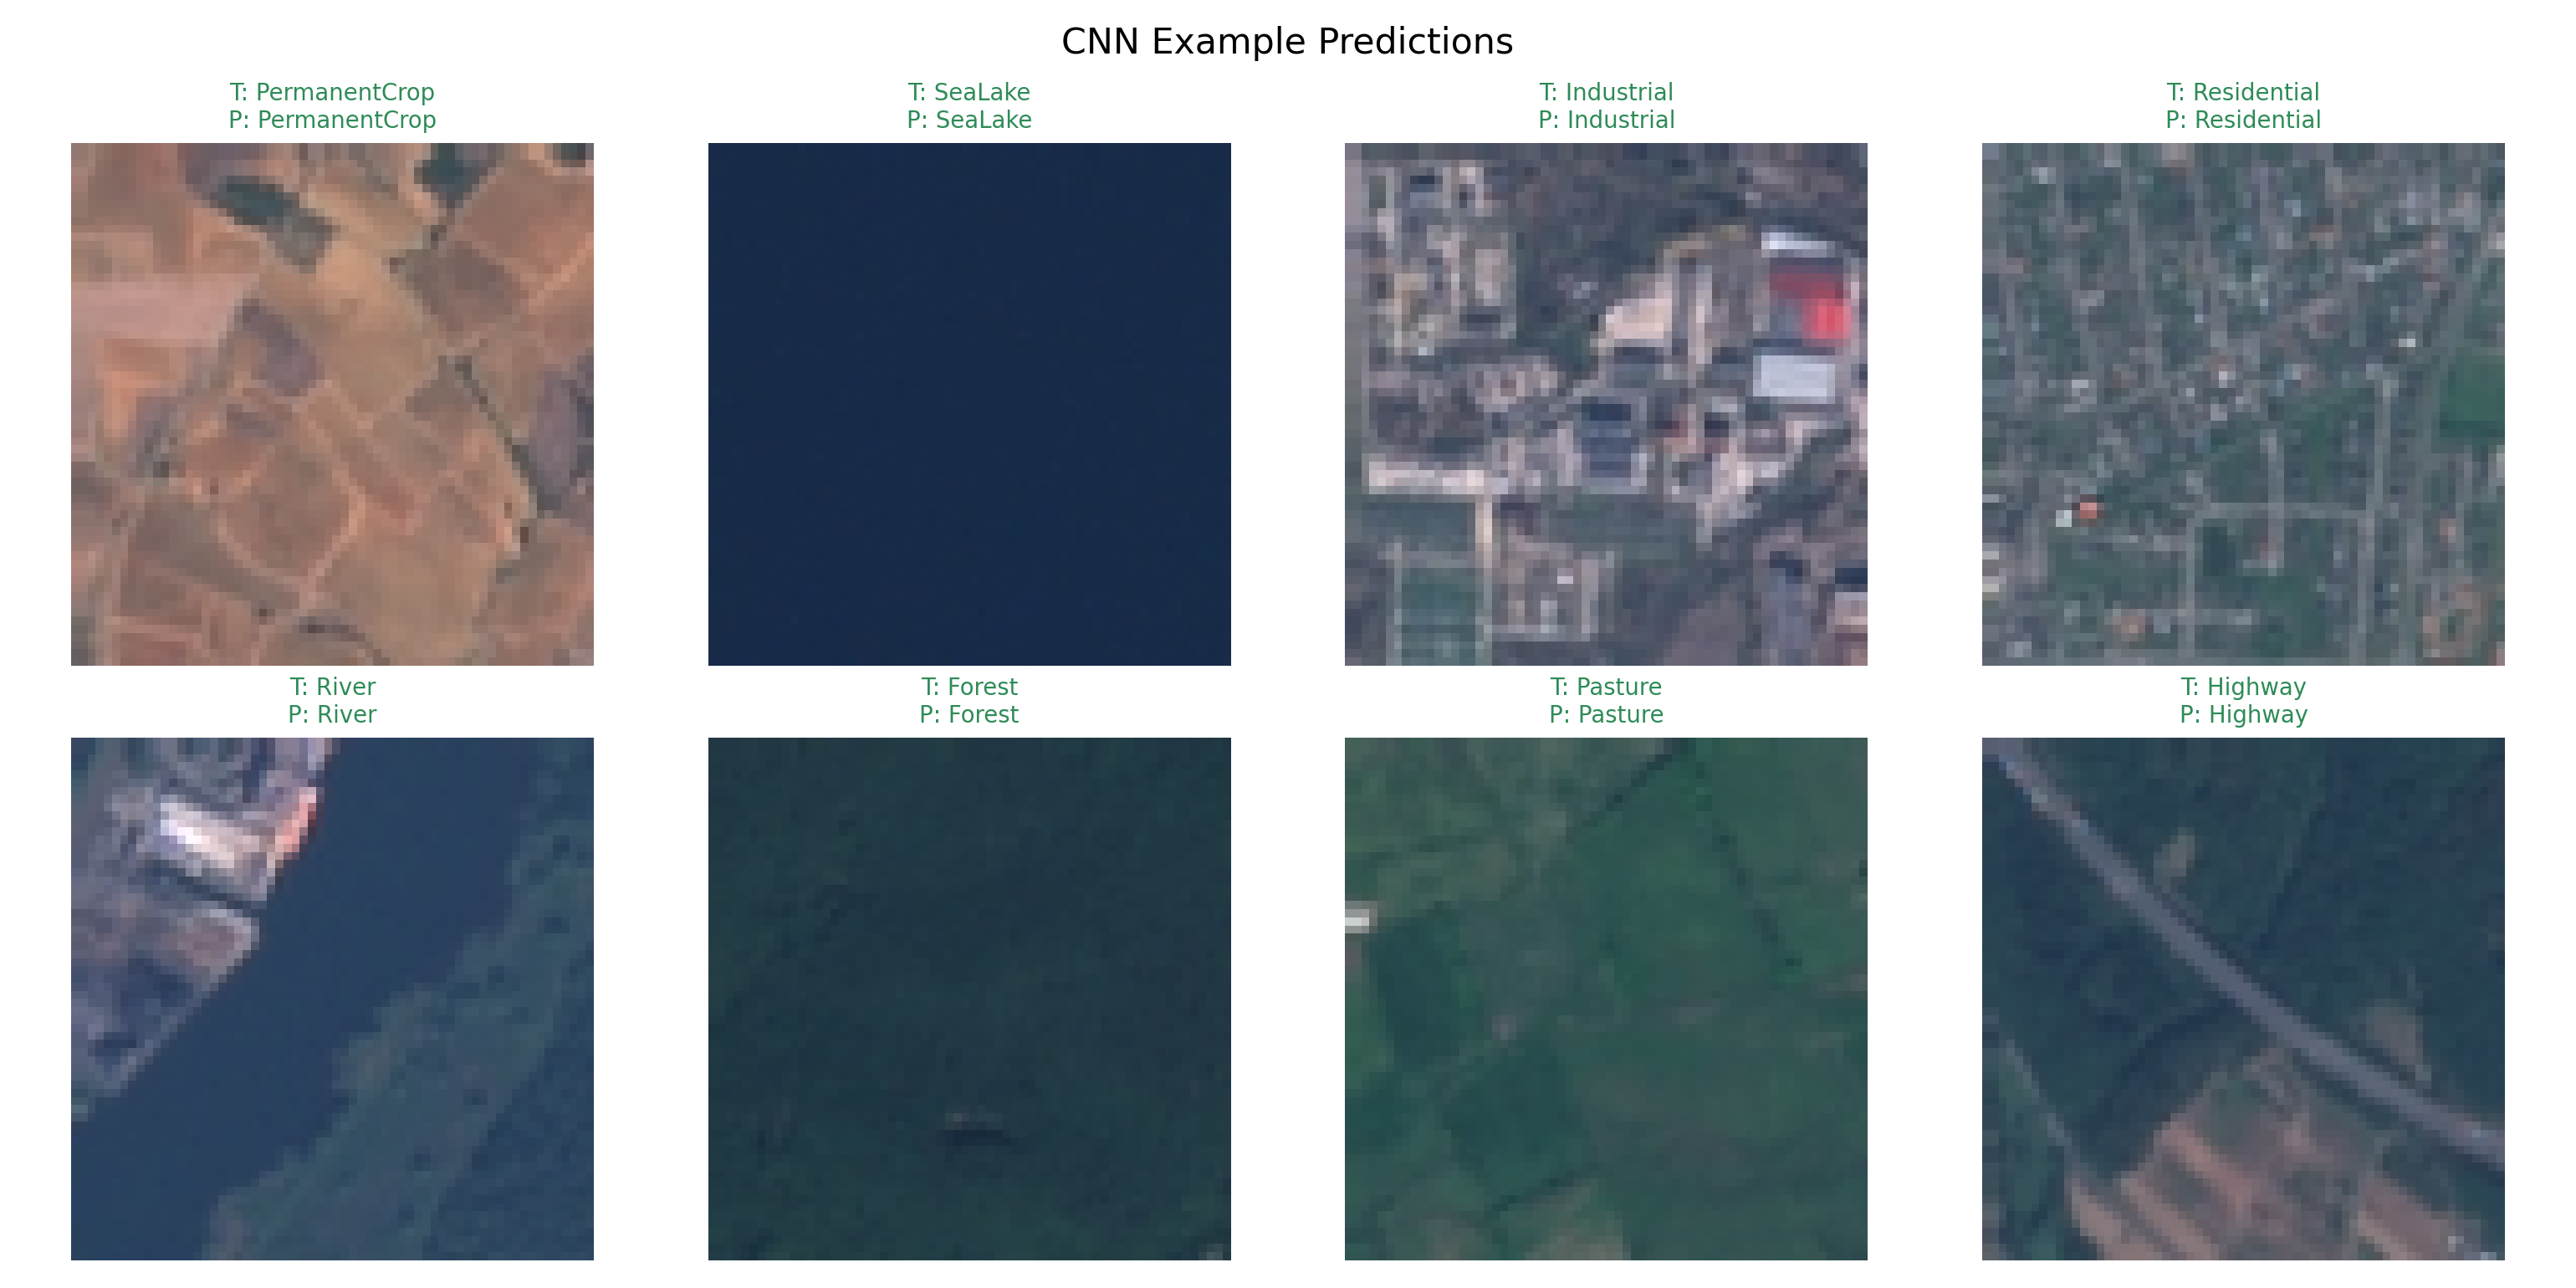

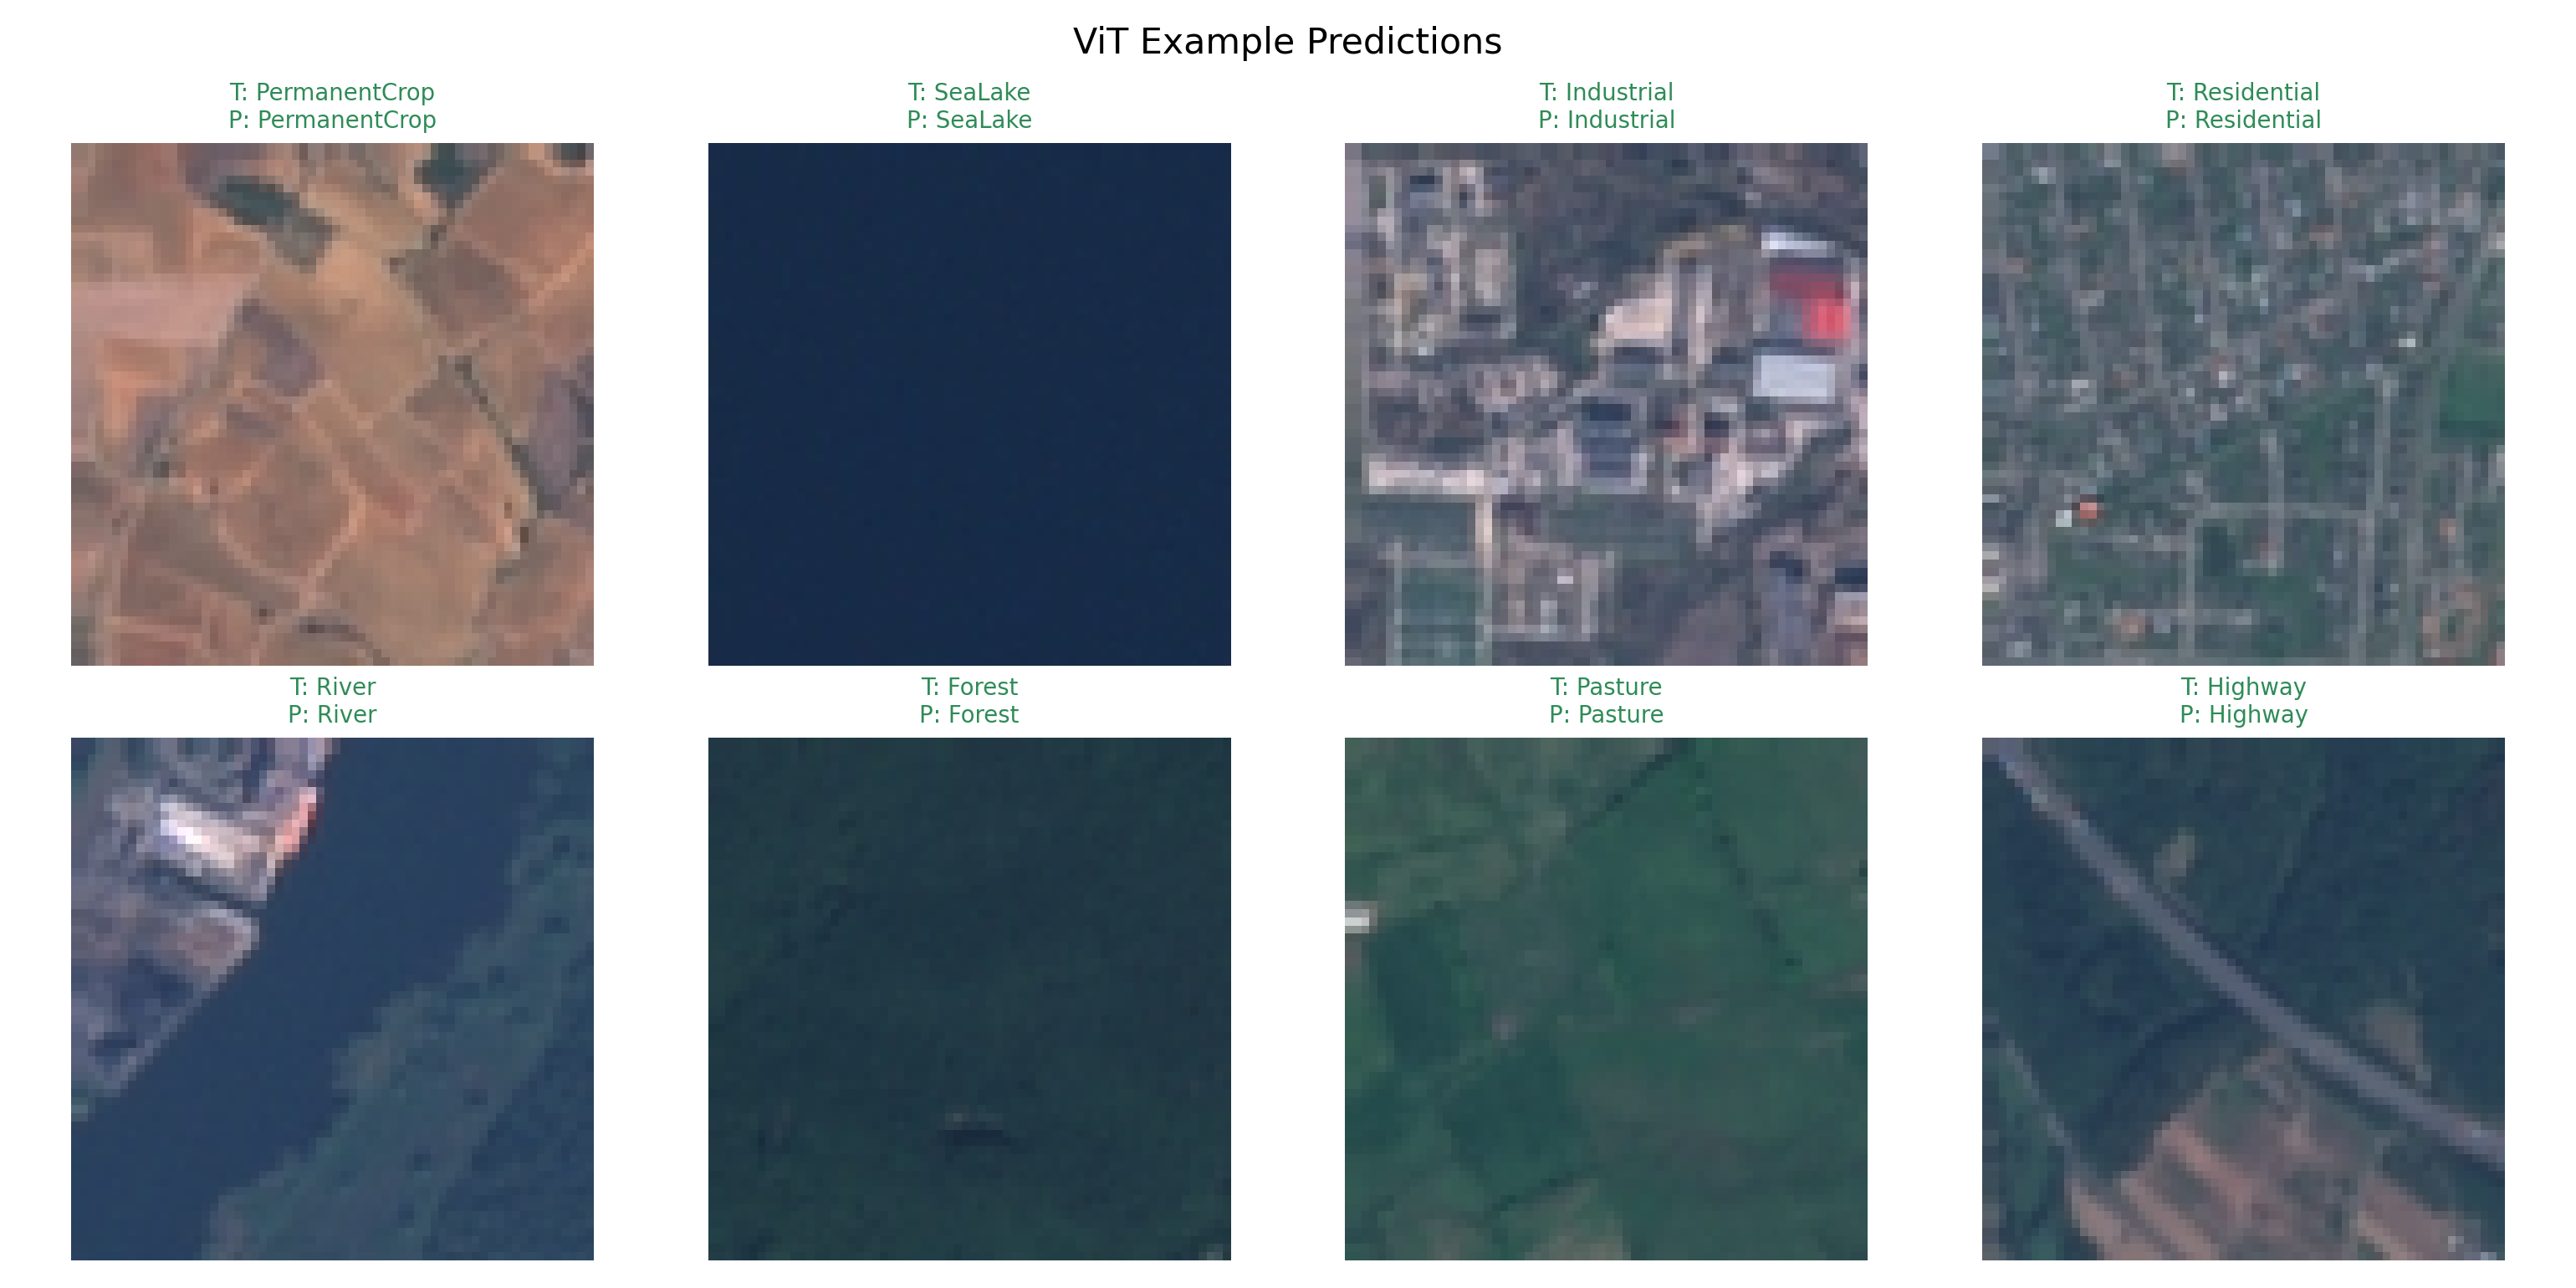

In [16]:
display(IPyImage(filename=str(FIG_DIR / 'rf_prediction_examples.png'), width=980))
display(IPyImage(filename=str(FIG_DIR / 'cnn_prediction_examples.png'), width=980))
display(IPyImage(filename=str(FIG_DIR / 'vit_prediction_examples.png'), width=980))

From these examples, the Random Forest branch appears to rely mainly on broad color and coarse spatial cues, while the CNN and ViT make more robust use of richer visual structure. That difference is particularly visible on categories that remain visually close in RGB.

### Training Dynamics

The training-history plots add an extra layer of evidence. They help confirm that the CNN and ViT are not only high-performing at the end point, but also converge in a stable and interpretable way under the selected fine-tuning setup.

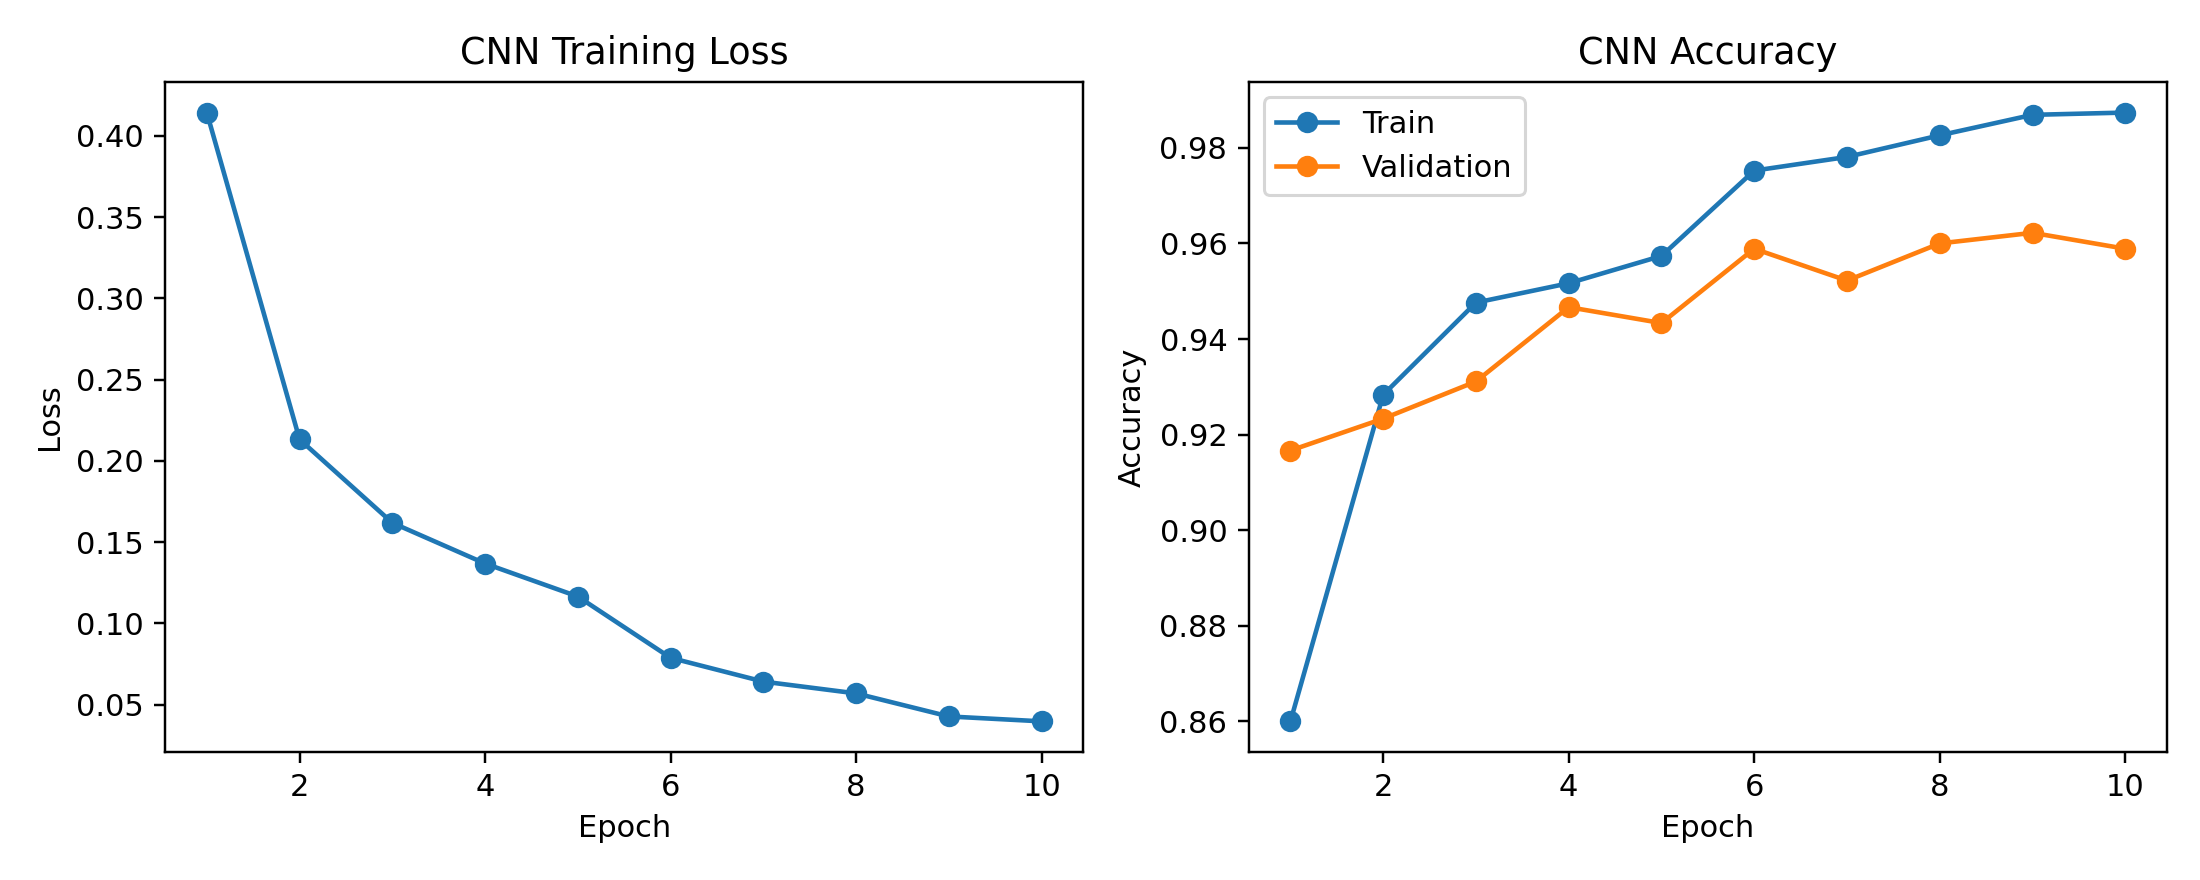

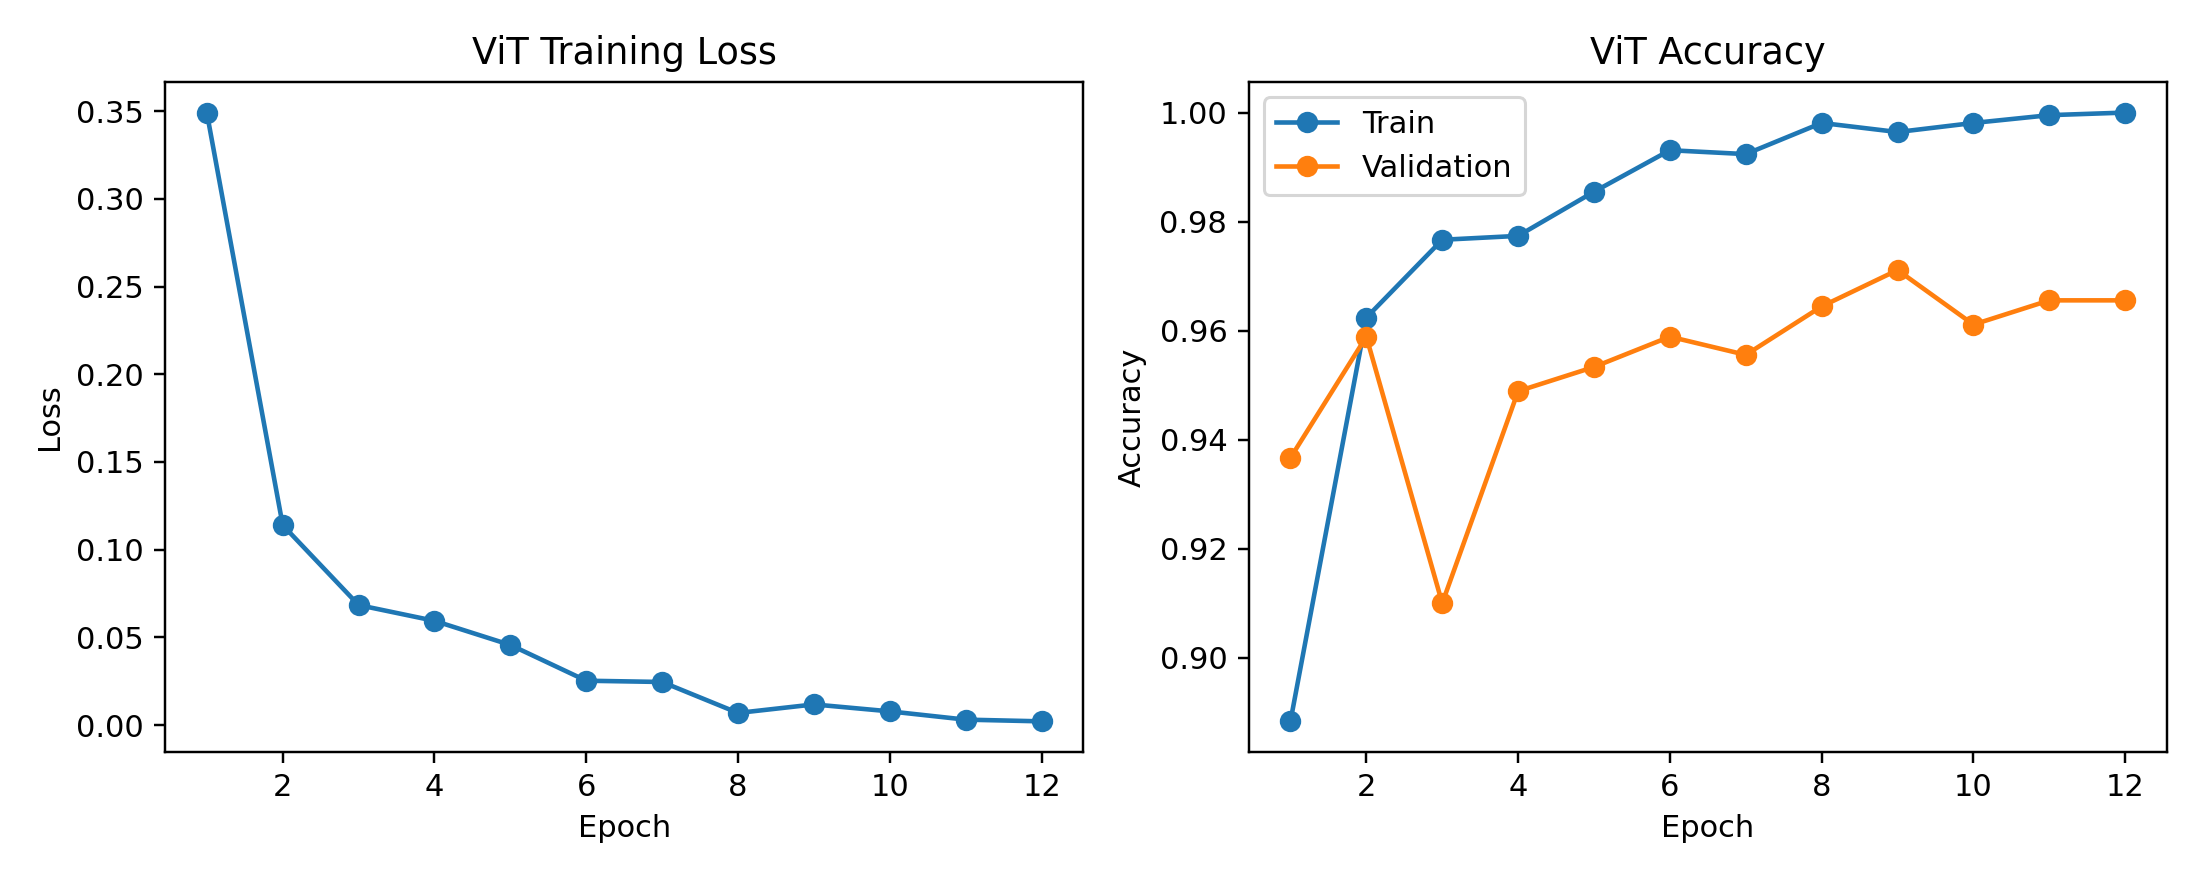

In [17]:
display(IPyImage(filename=str(FIG_DIR / 'cnn_training_history.png'), width=900))
display(IPyImage(filename=str(FIG_DIR / 'vit_training_history.png'), width=900))

## Environmental Cost Assessment

Once predictive performance has been fully examined, the notebook turns to environmental cost. This step matters because the strongest classifier is not automatically the most practical one, especially in a realistic AI4EO workflow where repeated experimentation and hardware limits must be considered.

,method,runtime_seconds,carbon_kgco2e,device,average_power_watts,pue,carbon_intensity_gco2_per_kwh
0,RandomForest,4.825740,0.000069,cpu,90.0,1.2,475.0
1,CNN,549.247265,0.007827,cuda,90.0,1.2,475.0
2,ViT,1137.790518,0.016214,cuda,90.0,1.2,475.0


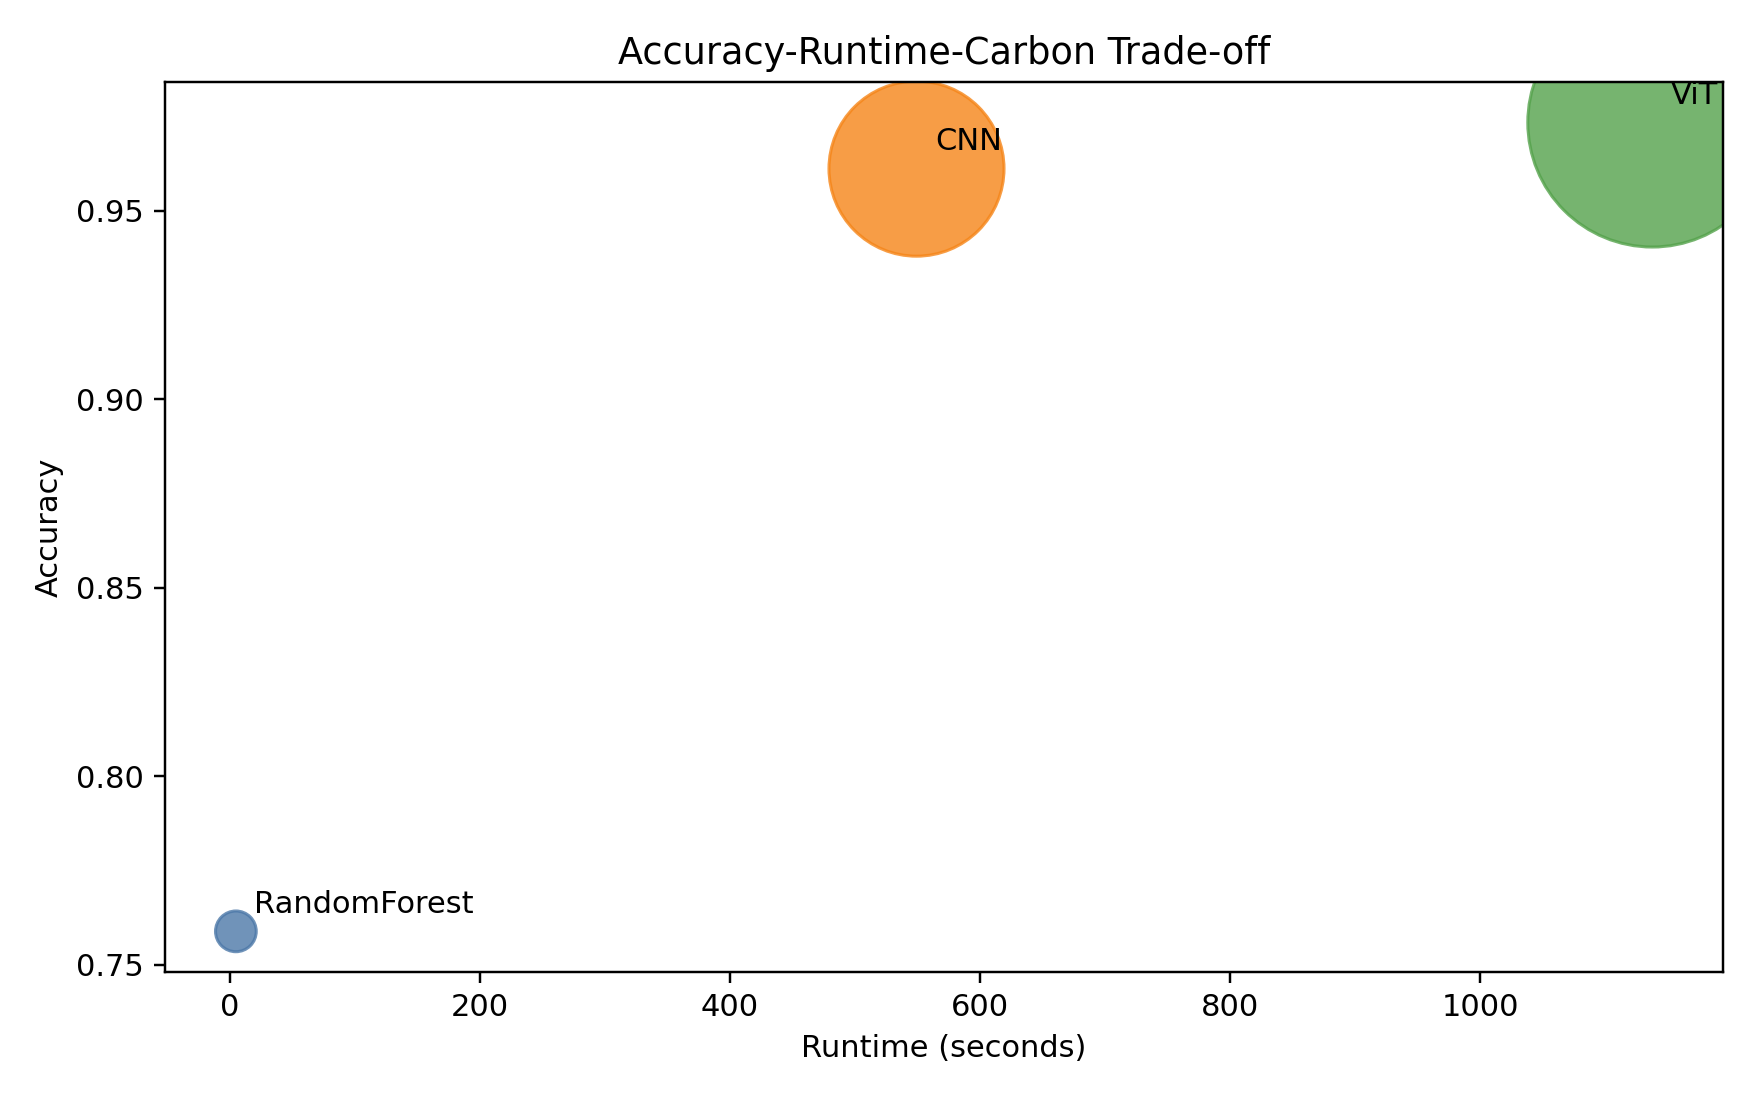

In [18]:
environment_table = pd.read_csv(TAB_DIR / 'environment_scenario_comparison.csv')
display(environment_table)
display(IPyImage(filename=str(FIG_DIR / 'accuracy_runtime_carbon_tradeoff.png'), width=900))

## Discussion

At this point the notebook has assembled enough evidence to move beyond reporting and into interpretation. The role of the discussion is not to repeat the numbers, but to explain what they mean in methodological terms.

The final evidence supports five main conclusions. First, pretrained transfer learning is highly effective on this benchmark. Second, the ViT achieves the strongest final accuracy and macro F1. Third, the CNN remains a very strong alternative and provides a convincing convolutional benchmark for EO classification. Fourth, the Random Forest baseline becomes much more competitive after feature engineering, showing that classical methods depend strongly on representation design. Fifth, the trade-off dimension remains central: the highest-accuracy model is not the cheapest model, so methodological choice depends on whether the application prioritizes peak accuracy, moderate compute cost, or minimal environmental burden.

## Limitations and Future Work

No benchmark study is complete without clarifying its boundaries. In this case, the main limitations are the use of EuroSAT RGB rather than the full multispectral archive, the use of a balanced subset rather than exhaustive full-archive training, and the fact that environmental accounting is assumption-based rather than directly measured.

These limits do not weaken the internal comparison, but they do define its scope. Natural future directions include multispectral experiments, scaling to the full archive, and adding explainable-AI analysis for class confusion and feature attribution.

## Concluding Perspective

Taken together, the experiments show that land-cover classification on this Sentinel-2 benchmark is not only a question of maximizing accuracy, but also of choosing an appropriate balance between predictive strength, computational cost, and interpretability. The optimized Random Forest baseline demonstrates that carefully designed hand-crafted features can still provide a meaningful low-cost benchmark. The CNN shows that pretrained convolutional transfer learning remains highly effective. The ViT, in turn, achieves the strongest final predictive performance, illustrating the potential of transformer-based vision models in AI4EO classification tasks.

The broader takeaway is that this benchmark works well as a small but meaningful laboratory for methodological comparison. It makes the strengths of each model family visible, and it also makes clear that in AI4EO the best model is not determined by accuracy alone, but by the balance between performance, cost, and practical use.